#

<div align=center>
<img src="https://uol.unifor.br/acesso/app/autenticacao/assets/img/logos/icon-unifor.svg" width=45 height=45>

<br><br>
<font size=5 color='black'><strong>MBA Ciência de dados:</strong> Estatística descritiva

<strong>Projeto:</strong> Titanic

<strong>Autoria:</strong> Heitor Teixeira

</div>

## <font color=darkblue> 1 - Imports e declaração de constantes e funções

### <font color=steelblue> 1.1 - Imports

In [181]:
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
import numpy as np
from scipy.stats import pearsonr

### <font color=steelblue> 1.2 - Constantes

Declarar constantes em uma unica celula facilita a manutenção de notebooks longos.<br>Alguns benefícios:
1. Melhorar a legibilidade do codigo
2. As constantes podem ser esquema de cores para padronizar sempre as mesmas cores para determinadas classes, paths de arquivos e datasets e etc.
3. posso modifica-las apenas aqui e servir para o codigo inteiro


In [182]:
# dataset do professor
PATH_ELEICOES = "datasets/eleicoes.csv"

# arquivos auxiliares do TSE para enriquecimento
PATH_CANDIDATOS = "datasets/extras/consulta_cand_2014_BRASIL.csv"
PATH_DESPESAS = "datasets/extras/despesas_candidatos_2014_brasil.txt"

PATH_DATASET_ENRIQUECIDO = "datasets/extras/eleicoes_enriquecido.csv"
PATH_FORNECEDORES = "datasets/extras/fornecedores_deputados.csv"

# paleta de cores para deixar os graficos padronizados
CORES = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#7B2D8B",
    "#4169E1",
    "#FF8C00",
    "#000000",
    "#006400",
    "#008080",
]

# tamanho padrao dos graficos
FIGSIZE = (12, 10)

# mapeamento de colunas: dataset original do professor
MAP_COLUMNS_ELEICOES = {
    "State": "Estado",
    "Candidate Number": "Numero Candidato",
    "Money (R$ Reais)": "Gasto",
    "Votes": "Votos",
}

# mapeamento de colunas: prestacao de contas TSE (despesas)
MAP_COLUMNS_DESPESAS = {
    "UF": "Estado",
    "Número candidato": "Numero Candidato",
    "Nome candidato": "Nome",
    "Sigla Partido": "Partido",
    "CPF do candidato": "CPF",
}

# mapeamento de colunas: cadastro oficial de candidatos TSE
MAP_COLUMNS_CANDIDATOS = {
    "SG_UF": "Estado",
    "NR_CANDIDATO": "Numero Candidato",
    "DS_SIT_TOT_TURNO": "Situacao",
    "DS_GENERO": "Genero",
    "DS_GRAU_INSTRUCAO": "Escolaridade",
    "DS_ESTADO_CIVIL": "Estado Civil",
    "DS_COR_RACA": "Raca",
    "DT_NASCIMENTO": "Dt Nascimento",
}

# mapeamento de situacao eleitoral para resultado consolidado
SITUACAO_MAP = {
    "ELEITO POR QP": "Eleito",
    "ELEITO POR MÉDIA": "Eleito",
    "SUPLENTE": "Suplente",
    "NÃO ELEITO": "Não Eleito",
}

### <font color=steelblue> 1.3 - Funções

**`plot_gasto_vs_votos`:** o scatter de gasto vs votos por situação eleitoral é um gráfico complexo: 
- 3 grupos de pontos
- 4 linhas verticais de referência com estilos distintos 
- 2 linhas horizontais de votos mínimos 
- escala log nos dois eixos. 
- salvar imagem com nomeclatura diferente para cada estado ou agrupamento de estados.

reproduzir esse bloco para cada estado seria impraticável. a função encapsula toda essa lógica e aceita um filtro de estados, permitindo gerar o mesmo gráfico para o brasil inteiro, um único estado ou qualquer subconjunto.

**`tabela_gasto_vs_votos`:** complementa o scatter com os valores numéricos agregados por resultado eleitoral. o título da tabela é passado como argumento pois a numeração depende do contexto onde é chamada.

In [183]:
def plot_gasto_vs_votos(df, estados=None):
    """
    Args:
        df      : DataFrame — eleicoes_enriquecido ou qualquer subconjunto
        estados : list[str] ou None — ex: ['SP'], ['SP', 'RJ']. None = todos os estados
    """
    data = df.copy()

    if estados is not None:
        data = data[data["Estado"].isin(estados)]

    mask = (
        (data["Gasto"] > 0)
        & (data["Votos"] > 0)
        & data["Situacao"].isin(SITUACAO_MAP)
    )
    data = data[mask].copy()
    data["Resultado"] = data["Situacao"].map(SITUACAO_MAP)

    cores_resultado = {"Eleito": CORES[2], "Suplente": CORES[0], "Não Eleito": CORES[3]}

    eleitos_gasto = data[data["Resultado"] == "Eleito"]["Gasto"]

    refs_verticais = {
        "Mín eleitos":     (eleitos_gasto.min(),   CORES[5], (4, 2)),
        "Mediana eleitos": (eleitos_gasto.median(), CORES[6], (8, 4)),
        "Média eleitos":   (eleitos_gasto.mean(),   CORES[7], (6, 3)),
        "Máx eleitos":     (eleitos_gasto.max(),    CORES[8], (2, 2)),
    }

    min_votos_media = data[data["Situacao"] == "ELEITO POR MÉDIA"]["Votos"].min()
    min_votos_qp    = data[data["Situacao"] == "ELEITO POR QP"]["Votos"].min()

    titulo_extra = f" — {', '.join(estados)}" if estados else ""
    nome_arquivo = "gasto_vs_votos" + ("_" + "_".join(estados) if estados else "")

    fig, ax = plt.subplots(figsize=FIGSIZE)

    for resultado, grupo in data.groupby("Resultado"):
        ax.scatter(
            grupo["Gasto"],
            grupo["Votos"],
            c=cores_resultado[resultado],
            label=f"{resultado} (n={len(grupo)})",
            alpha=0.6,
            s=36,
            edgecolors="none",
        )

    for label, (valor, cor, dash) in refs_verticais.items():
        ax.axvline(valor, color=cor, linestyle="--", dashes=dash, label=f"{label}: R$ {valor:,.0f}")

    if not pd.isna(min_votos_media):
        ax.axhline(min_votos_media, color=CORES[9], linestyle="-.", label=f"Mín votos eleito por média: {min_votos_media:,}")
    if not pd.isna(min_votos_qp):
        ax.axhline(min_votos_qp, color=CORES[10], linestyle="-.", label=f"Mín votos eleito por QP: {min_votos_qp:,}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Gasto (R$) — escala log")
    ax.set_ylabel("Votos — escala log")
    ax.set_title(f"Gasto vs Votos por Situação Eleitoral — Deputado Federal 2014{titulo_extra}")
    ax.legend(markerscale=2)
    plt.tight_layout()
    plt.savefig(f"assets/elections/{nome_arquivo}.png")
    plt.show()

In [184]:
def tabela_gasto_vs_votos(df, titulo, estados=None):
    """
    Args:
        df      : DataFrame — eleicoes_enriquecido ou qualquer subconjunto
        titulo  : str — ex: 'Tabela 3.6 - Gasto e Votos por Resultado Eleitoral'
        estados : list[str] ou None — ex: ['SP'], ['SP', 'RJ']. None = todos os estados
    """
    data = df.copy()

    if estados is not None:
        data = data[data["Estado"].isin(estados)]

    mask = (
        (data["Gasto"] > 0)
        & (data["Votos"] > 0)
        & data["Situacao"].isin(SITUACAO_MAP)
    )
    data = data[mask].copy()
    data["Resultado"] = data["Situacao"].map(SITUACAO_MAP)

    ordem = ["Eleito", "Suplente", "Não Eleito"]

    tabela = (
        data.groupby("Resultado")
        .agg(
            N=("Gasto", "count"),
            Gasto_Media=("Gasto", "mean"),
            Gasto_Mediana=("Gasto", "median"),
            Gasto_Min=("Gasto", "min"),
            Gasto_Max=("Gasto", "max"),
            Votos_Media=("Votos", "mean"),
            Votos_Mediana=("Votos", "median"),
        )
        .reindex(ordem)
    )

    total = pd.Series({
        "N": data["Gasto"].count(),
        "Gasto_Media": data["Gasto"].mean(),
        "Gasto_Mediana": data["Gasto"].median(),
        "Gasto_Min": data["Gasto"].min(),
        "Gasto_Max": data["Gasto"].max(),
        "Votos_Media": data["Votos"].mean(),
        "Votos_Mediana": data["Votos"].median(),
    }, name="Total")
    tabela = pd.concat([tabela, total.to_frame().T])

    tabela["N"] = tabela["N"].map("{:,.0f}".format)
    for col in ["Gasto_Media", "Gasto_Mediana", "Gasto_Min", "Gasto_Max"]:
        tabela[col] = tabela[col].map("R$ {:,.0f}".format)
    for col in ["Votos_Media", "Votos_Mediana"]:
        tabela[col] = tabela[col].map("{:,.0f}".format)

    tabela.columns = ["N", "Gasto Médio", "Gasto Mediana", "Gasto Mín", "Gasto Máx", "Votos Médios", "Votos Mediana"]

    print(titulo)
    display(tabela)

## <font color=darkblue> 2 - Carregamento e Preparação do Dataset

### <font color=steelblue> 2.1 - Carregando o dataset original

**Observações:**
- o dataset original fornecido pelo professor contém dados de candidatos a Deputado Federal nas eleições de 2014
- cada linha representa um candidato, identificado por Estado e Número de Candidato
- as colunas originais foram renomeadas para português via `MAP_COLUMNS_ELEICOES`
- o csv tem espaco nos valores. quando o valor é numerico não tem problema, python reconhece. mas em string é preciso dar o strip().


In [185]:
eleicoes_df = pd.read_csv(PATH_ELEICOES, header=0, names=MAP_COLUMNS_ELEICOES.values())

# strip() na caoluna str
eleicoes_df["Estado"] = eleicoes_df["Estado"].str.strip()

### <font color=steelblue> 2.2 - Feature Engineering

**Observações:**

O enriquecimento dos dados não foi solicitado, mas reflete uma postura natural do cientista de dados: ir além do dataset fornecido para extrair análises com maior contexto e relevância. Dados isolados, sem um objetivo bem definido dizem pouco. Os dados adicionais dão direção e profundidade para a análise. 

- enriqueci o dataset original com dois arquivos públicos do TSE: prestação de contas de despesas e cadastro oficial de candidatos
- os três arquivos são lidos uma única vez e todos os joins são feitos nesta seção, evitando releituras ao longo do notebook
- a chave de join utilizada é `Estado` + `Numero Candidato` em ambos os merges
- de `despesas_candidatos_2014_brasil.txt`: extrai nome, partido, cargo e CPF por candidato (via `drop_duplicates`) e agrega quantidade de notas e total declarado ao TSE (via `groupby`)
- de `consulta_cand_2014_BRASIL.csv`: filtrei apenas candidatos com número de 4 dígitos, padrão exclusivo de Deputado Federal, e extraí gênero, escolaridade, raça, estado civil e resultado eleitoral

#### <font color=slategray> 2.2.1 - Aquisição de dados externos

**Observações:**

carrego dois arquivos auxiliares do TSE para enriquecer o dataset original:

| Dataset | Arquivo | Uso |
|---|---|---|
| `eleicoes.csv` | Dataset original fornecido | Gasto total e votos por candidato |
| Prestação de Contas 2014 | `despesas_candidatos_2014_brasil.txt` | Validação dos valores, nome, partido, cargo e quantidade de notas |
| Cadastro de Candidatos 2014 | `consulta_cand_2014_BRASIL.csv` | Situação eleitoral, gênero, raça, escolaridade, data de nascimento |

**Fonte:** [dadosabertos.tse.jus.br](https://dadosabertos.tse.jus.br), Eleições Gerais 2014, Deputado Federal.

> Os dados referem-se à **prestação de contas final** (após revisão pelo TSE).

In [186]:
# essa celula é pra rodar só uma vez pra gerar o dataset enriquecido e depois comentar.
"""
despesas_df = pd.read_csv(
    PATH_DESPESAS,
    sep=";",
    encoding="latin1",
    decimal=",",
    usecols=[
        "UF",
        "Número candidato",
        "Nome candidato",
        "Sigla Partido",
        "Cargo",
        "CPF do candidato",
        "Valor despesa",
    ],
    dtype={"CPF do candidato": str},
)

cand_df = pd.read_csv(
    PATH_CANDIDATOS,
    sep=";",
    encoding="latin1",
    usecols=["SG_UF", "NR_CANDIDATO"] + list(MAP_COLUMNS_CANDIDATOS.keys()),
)
"""

'\ndespesas_df = pd.read_csv(\n    PATH_DESPESAS,\n    sep=";",\n    encoding="latin1",\n    decimal=",",\n    usecols=[\n        "UF",\n        "Número candidato",\n        "Nome candidato",\n        "Sigla Partido",\n        "Cargo",\n        "CPF do candidato",\n        "Valor despesa",\n    ],\n    dtype={"CPF do candidato": str},\n)\n\ncand_df = pd.read_csv(\n    PATH_CANDIDATOS,\n    sep=";",\n    encoding="latin1",\n    usecols=["SG_UF", "NR_CANDIDATO"] + list(MAP_COLUMNS_CANDIDATOS.keys()),\n)\n'

#### <font color=slategray> 2.2.2 - Agregações e merges

**Observações:**

- como o arquivo de despesas tem uma linha por nota fiscal, agreguei por candidato antes do join: `Qtd_Notas` (count) e `Total_Despesas_TSE` (sum). qualitativas extraidas via `drop_duplicates`
- o arquivo do TSE contém todos os candidatos das eleições de 2014, nao apenas deputados federais.
- filtrei apenas registros com numero de 4 digitos, padrao exclusivo de deputado federal. candidatos a outros cargos usam 2, 3 ou 5 digitos
- chave de join utilizada em ambos os merges: `Estado` + `Numero Candidato` pois podem existir candidatos com numeros iguais de estados diferentes.

In [187]:
"""
qtd_notas = (
    despesas_df.groupby(["UF", "Número candidato"])
    .agg(
        Qtd_Notas=("Valor despesa", "count"),
        Total_Despesas_TSE=("Valor despesa", "sum"),
    )
    .reset_index()
    .rename(columns=MAP_COLUMNS_DESPESAS)
)

candidatos_despesas = (
    despesas_df.drop_duplicates(subset=["UF", "Número candidato"])
    .rename(columns=MAP_COLUMNS_DESPESAS)
    .merge(qtd_notas, on=["Estado", "Numero Candidato"], how="left")[
        [
            "Estado",
            "Numero Candidato",
            "Nome",
            "Partido",
            "Cargo",
            "CPF",
            "Qtd_Notas",
            "Total_Despesas_TSE",
        ]
    ]
)

candidatos = (
    cand_df[cand_df["NR_CANDIDATO"].astype(str).str.len() == 4]
    .drop_duplicates(subset=["SG_UF", "NR_CANDIDATO"])
    .rename(columns=MAP_COLUMNS_CANDIDATOS)
)

eleicoes_enriquecido = eleicoes_df.merge(
    candidatos_despesas, on=["Estado", "Numero Candidato"], how="left"
).merge(candidatos, on=["Estado", "Numero Candidato"], how="left")

eleicoes_enriquecido["Qtd_Notas"] = (
    eleicoes_enriquecido["Qtd_Notas"].fillna(0).astype(int)
)

eleicoes_enriquecido.to_csv(PATH_DATASET_ENRIQUECIDO, index=False)
"""

'\nqtd_notas = (\n    despesas_df.groupby(["UF", "Número candidato"])\n    .agg(\n        Qtd_Notas=("Valor despesa", "count"),\n        Total_Despesas_TSE=("Valor despesa", "sum"),\n    )\n    .reset_index()\n    .rename(columns=MAP_COLUMNS_DESPESAS)\n)\n\ncandidatos_despesas = (\n    despesas_df.drop_duplicates(subset=["UF", "Número candidato"])\n    .rename(columns=MAP_COLUMNS_DESPESAS)\n    .merge(qtd_notas, on=["Estado", "Numero Candidato"], how="left")[\n        [\n            "Estado",\n            "Numero Candidato",\n            "Nome",\n            "Partido",\n            "Cargo",\n            "CPF",\n            "Qtd_Notas",\n            "Total_Despesas_TSE",\n        ]\n    ]\n)\n\ncandidatos = (\n    cand_df[cand_df["NR_CANDIDATO"].astype(str).str.len() == 4]\n    .drop_duplicates(subset=["SG_UF", "NR_CANDIDATO"])\n    .rename(columns=MAP_COLUMNS_CANDIDATOS)\n)\n\neleicoes_enriquecido = eleicoes_df.merge(\n    candidatos_despesas, on=["Estado", "Numero Candidato"], how="le

#### <font color=slategray> 2.2.3 - Dataset enriquecido

**Observações:**

- o dataset enriquecido foi gerado uma unica vez e salvo em `eleicoes_enriquecido.csv`. nas proximas execucoes, carrego direto do arquivo salvo sem precisar reler e agregar os arquivos do TSE

In [188]:
eleicoes_enriquecido = pd.read_csv(PATH_DATASET_ENRIQUECIDO)

print(f"Tabela 2.2.3 - Dataset enriquecido ({len(eleicoes_enriquecido)} candidatos)")
display(eleicoes_enriquecido.head(5).set_index("Numero Candidato"))

Tabela 2.2.3 - Dataset enriquecido (6353 candidatos)


,Estado,Gasto,Votos,Nome,Partido,Cargo,CPF,Qtd_Notas,Total_Despesas_TSE,Dt Nascimento,Genero,Escolaridade,Estado Civil,Raca,Situacao
Numero Candidato,,,,,,,,,,,,,,,
1919,AC,35504.34,515,JUAREZ PEDROSA CAVALCANTE,PTN,Deputado Federal,1.333425e+10,30,35504.34,24/02/1961,MASCULINO,ENSINO MÉDIO COMPLETO,DIVORCIADO(A),PARDA,SUPLENTE
1212,AC,397136.76,11397,JOSÉ LUIS SCHAFER,PDT,Deputado Federal,3.142027e+10,223,397136.76,20/06/1960,MASCULINO,SUPERIOR COMPLETO,CASADO(A),BRANCA,SUPLENTE
5012,AC,1580.00,15,ANA PAULA MORAIS DE HOLANDA,PSOL,Deputado Federal,8.214671e+10,3,1580.00,10/11/1985,FEMININO,ENSINO MÉDIO COMPLETO,SOLTEIRO(A),PARDA,NÃO ELEITO
1321,AC,66093.33,1913,ROSELI COSTA,PT,Deputado Federal,3.080045e+10,21,66093.33,04/06/1970,FEMININO,SUPERIOR COMPLETO,CASADO(A),PARDA,SUPLENTE
1144,AC,296327.21,13610,VANDA DENIR MILANI NOGUEIRA,PP,Deputado Federal,7.858185e+10,178,296327.21,17/09/1953,FEMININO,SUPERIOR COMPLETO,CASADO(A),BRANCA,SUPLENTE


#### <font color=slategray> 2.2.4 - Dataset de fornecedores

**Observações:**

crio um dataset separado com todos os fornecedores de candidatos a Deputado Federal, agregado por combinação candidato x fornecedor. a chave de join é `(Estado, Numero Candidato)`, permitindo cruzar com `eleicoes_enriquecido` para análises por resultado eleitoral, partido ou estado. também permite agregar por fornecedor para ranking de quem mais recebeu.

In [189]:
# essa celula é pra rodar só uma vez pra gerar o dataset de fornecedores e depois comentar.
'''
_despesas = pd.read_csv(
    PATH_DESPESAS,
    sep=";",
    encoding="latin1",
    decimal=",",
    usecols=[
        "UF",
        "Número candidato",
        "CPF do candidato",
        "Cargo",
        "CPF/CNPJ do fornecedor",
        "Nome do fornecedor",
        "Setor econômico do fornecedor",
        "Valor despesa",
    ],
    dtype={"CPF do candidato": str},
)

fornecedores_df = (
    _despesas[_despesas["Cargo"] == "Deputado Federal"]
    .groupby(
        ["UF", "Número candidato", "CPF do candidato",
         "CPF/CNPJ do fornecedor", "Nome do fornecedor", "Setor econômico do fornecedor"]
    )
    .agg(
        Total_Recebido=("Valor despesa", "sum"),
        Qtd_Notas=("Valor despesa", "count"),
    )
    .reset_index()
    .rename(columns={
        "UF": "Estado",
        "Número candidato": "Numero Candidato",
        "CPF do candidato": "CPF",
        "CPF/CNPJ do fornecedor": "CNPJ Fornecedor",
        "Nome do fornecedor": "Nome Fornecedor",
        "Setor econômico do fornecedor": "Setor",
    })
    .sort_values("Total_Recebido", ascending=False)
)

fornecedores_df.to_csv(PATH_FORNECEDORES, index=False)
'''

'\n_despesas = pd.read_csv(\n    PATH_DESPESAS,\n    sep=";",\n    encoding="latin1",\n    decimal=",",\n    usecols=[\n        "UF",\n        "Número candidato",\n        "CPF do candidato",\n        "Cargo",\n        "CPF/CNPJ do fornecedor",\n        "Nome do fornecedor",\n        "Setor econômico do fornecedor",\n        "Valor despesa",\n    ],\n    dtype={"CPF do candidato": str},\n)\n\nfornecedores_df = (\n    _despesas[_despesas["Cargo"] == "Deputado Federal"]\n    .groupby(\n        ["UF", "Número candidato", "CPF do candidato",\n         "CPF/CNPJ do fornecedor", "Nome do fornecedor", "Setor econômico do fornecedor"]\n    )\n    .agg(\n        Total_Recebido=("Valor despesa", "sum"),\n        Qtd_Notas=("Valor despesa", "count"),\n    )\n    .reset_index()\n    .rename(columns={\n        "UF": "Estado",\n        "Número candidato": "Numero Candidato",\n        "CPF do candidato": "CPF",\n        "CPF/CNPJ do fornecedor": "CNPJ Fornecedor",\n        "Nome do fornecedor": "Nome

In [190]:
fornecedores_df = pd.read_csv(PATH_FORNECEDORES)

print(f"Tabela 2.2.4 - Dataset de fornecedores ({len(fornecedores_df):,} registros)")
display(fornecedores_df.head(5).set_index("Numero Candidato"))

Tabela 2.2.4 - Dataset de fornecedores (366,289 registros)


,Estado,CPF,CNPJ Fornecedor,Nome Fornecedor,Setor,Total_Recebido,Qtd_Notas
Numero Candidato,,,,,,,
1530,RJ,50447971700,04712797000100,COOPGUANABARA - COOPERATIVA DOS TRABALHADORES ...,Outras atividades de serviços prestados princi...,3697968.19,61
1414,RJ,3625801701,19799580000157,JSM SERVICOS GRAFICOS LTDA,Impressão de material para uso publicitário,2699610.00,89
1322,SP,6821146187,10221070000123,VTPB - SERVICOS GRAFICOS E MIDIA EXTERIOR LTDA...,Impressão de material para uso publicitário,2083995.00,19
1125,RJ,3441067720,04342065000176,AMERICAN 2001 SIGN COMUNICACAO VISUAL LTDA - ME,"Fabricação de letras, letreiros e placas de qu...",1897794.40,108
7777,SP,21006768904,19377221000101,SOLIDARIEDADE - SDD - REGIONAL SP.,Atividades de organizações políticas,1679287.85,322


### <font color=steelblue> 2.3 - Validação dos dados mesclados

**Observações:**

apos o enriquecimento, o dataset possui duas colunas de gasto: `Gasto` (fornecida pelo professor) e `Total_Despesas_TSE` (calculada a partir da soma das despesas declaradas ao TSE). a validacao e feita em duas frentes:
- completude: todos os candidatos do dataset original estao presentes no TSE?
- consistencia: os valores de `Gasto` e `Total_Despesas_TSE` sao compativeis?

#### <font color=slategray> 2.3.1 - Completude

cruzei todos os candidatos do dataset original com o arquivo de prestacao de contas do TSE. candidatos sem match na coluna `Nome` sao aqueles sem nenhuma nota fiscal registrada. candidatos com `Gasto = 0` sem match sao esperados. candidatos com `Gasto > 0` sem match sao inconsistencias.

In [191]:
sem_match = eleicoes_enriquecido["Nome"].isna()
sem_match_zero = sem_match & (eleicoes_enriquecido["Gasto"] == 0)
sem_match_valor = sem_match & (eleicoes_enriquecido["Gasto"] > 0)
encontrados = ~sem_match

resumo_completude = pd.DataFrame(
    {
        "Situacao": [
            "Total de candidatos no dataset original",
            "Encontrados nos dados TSE 2014",
            "Nao encontrados com Gasto = R$ 0 (sem despesas declaradas)",
            "Nao encontrados com Gasto > 0 (inconsistencias)",
        ],
        "Quantidade": [
            len(eleicoes_enriquecido),
            encontrados.sum(),
            sem_match_zero.sum(),
            sem_match_valor.sum(),
        ],
    }
)
resumo_completude["% do Total"] = (
    resumo_completude["Quantidade"] / len(eleicoes_enriquecido) * 100
).map("{:.2f}%".format)
resumo_completude["Quantidade"] = resumo_completude["Quantidade"].map("{:,}".format)

print("Tabela 2.3.1 - Completude do cruzamento entre eleicoes.csv e TSE 2014")
display(resumo_completude.set_index("Situacao"))

Tabela 2.3.1 - Completude do cruzamento entre eleicoes.csv e TSE 2014


,Quantidade,% do Total
Situacao,,
Total de candidatos no dataset original,"6,353",100.00%
Encontrados nos dados TSE 2014,"5,392",84.87%
Nao encontrados com Gasto = R$ 0 (sem despesas declaradas),957,15.06%
Nao encontrados com Gasto > 0 (inconsistencias),4,0.06%


**Observações:**
- candidatos com `Gasto = 0` sem match no TSE sao esperados: o TSE so gera registro quando ha ao menos uma nota fiscal
- os poucos casos com `Gasto > 0` sem match representam inconsistencias pontuais e serao detalhados na secao 2.3.2
- apenas 4 candidatos não foram encontrados no dataset do TSE

#### <font color=slategray> 2.3.2 - Consistência dos valores

para os candidatos encontrados em ambos os datasets com `Gasto > 0`, comparei `Gasto` (eleicoes.csv) com `Total_Despesas_TSE` (soma das notas do TSE). classifico as diferencas em tres categorias: 
1. match exato  `< R$ 0.01`
2. diferenca residual de arredondamento `>= R$ 0.01` & `< R$ 1.00`
3. divergencia real. `>= R$ 1.00`

In [192]:
# candidatos com Gasto > 0 sem match no TSE
nao_encontrados = eleicoes_enriquecido[sem_match_valor][
    ["Estado", "Numero Candidato", "Gasto"]
].copy()
nao_encontrados["Total_Despesas_TSE"] = 0.0
nao_encontrados["Diferenca"] = nao_encontrados["Gasto"]

print("Tabela 2.3.2a - Candidatos com Gasto > 0 nao encontrados no TSE")
display(nao_encontrados.reset_index(drop=True))

# consistencia para os candidatos cruzados com Gasto > 0
mask_cruzados = eleicoes_enriquecido["Total_Despesas_TSE"].notna() & (
    eleicoes_enriquecido["Gasto"] > 0
)
comparacao = eleicoes_enriquecido[mask_cruzados].copy()
comparacao["Diferenca"] = (comparacao["Gasto"] - comparacao["Total_Despesas_TSE"]).abs()

mask_match = comparacao["Diferenca"] < 0.01  # match exato
mask_residual = (comparacao["Diferenca"] >= 0.01) & (
    comparacao["Diferenca"] < 1
)  # match quase exato
mask_diverge = comparacao["Diferenca"] >= 1

resumo_consistencia = pd.DataFrame(
    {
        "Situacao": [
            "Match exato (diferenca < R$ 0,01)",
            "Diferenca residual (R$ 0,01 a R$ 1,00)",
            "Divergencia de valor (> R$ 1,00)",
            "Total candidatos cruzados",
        ],
        "Quantidade": [
            mask_match.sum(),
            mask_residual.sum(),
            mask_diverge.sum(),
            len(comparacao),
        ],
    }
)

resumo_consistencia["% do Cruzado"] = (
    resumo_consistencia["Quantidade"] / len(comparacao) * 100
).map("{:.2f}%".format)

resumo_consistencia["Quantidade"] = resumo_consistencia["Quantidade"].map("{:,}".format)

print("Tabela 2.3.2b - Consistencia entre Gasto (eleicoes.csv) e Total_Despesas_TSE")
display(resumo_consistencia.set_index("Situacao"))

print(f"\nDiferenca maxima: R$ {comparacao['Diferenca'].max():,.2f}")
print(f"Diferenca media:  R$ {comparacao['Diferenca'].mean():,.4f}")

Tabela 2.3.2a - Candidatos com Gasto > 0 nao encontrados no TSE


,Estado,Numero Candidato,Gasto,Total_Despesas_TSE,Diferenca
0,GO,3690,600.00,0.0,600.00
1,GO,3134,100.00,0.0,100.00
2,MG,3686,300.00,0.0,300.00
3,SP,1303,118209.44,0.0,118209.44


Tabela 2.3.2b - Consistencia entre Gasto (eleicoes.csv) e Total_Despesas_TSE


,Quantidade,% do Cruzado
Situacao,,
"Match exato (diferenca < R$ 0,01)","5,054",95.02%
"Diferenca residual (R$ 0,01 a R$ 1,00)",1,0.02%
"Divergencia de valor (> R$ 1,00)",264,4.96%
Total candidatos cruzados,"5,319",100.00%



Diferenca maxima: R$ 966,926.11
Diferenca media:  R$ 585.0874


**Observações:**
- a soma das despesas do TSE reproduz os valores do dataset original na grande maioria dos casos
- diferencas residuais (< R$ 1,00) sao atribuiveis a arredondamento de ponto flutuante
- `eleicoes.csv` e derivado do campo `Valor despesa` da prestacao de contas do TSE
- divergencias acima de R$ 1,00 sugerem que `eleicoes.csv` foi compilado a partir de uma versao anterior da prestacao de contas, anterior a revisao final pelo TSE
- a diferenca de versao nao compromete a analise: `Gasto` permanece como a medida oficial do gasto declarado

#### <font color=slategray> 2.3.3 - Análise comparativa

**Observações:**

Removi todos os dados de candidatos com `Gasto = 0`. Por que?
- as análises são de gastos, um candidato que não gastou durante toda a eleição provavelmente é alguém que desistiu de sua campanha
- o número de candidatos que não gastaram é algo relavante dentro de todo dataset `~15%`. esse número é razoável e pode afetar métricas como média e mediana.
- `TODOS` os candidatos eleitos, de acordo com o TSE, gastaram alguma coisa. Portanto, não faz sentido em análises comparativas deixa-los no dataset.

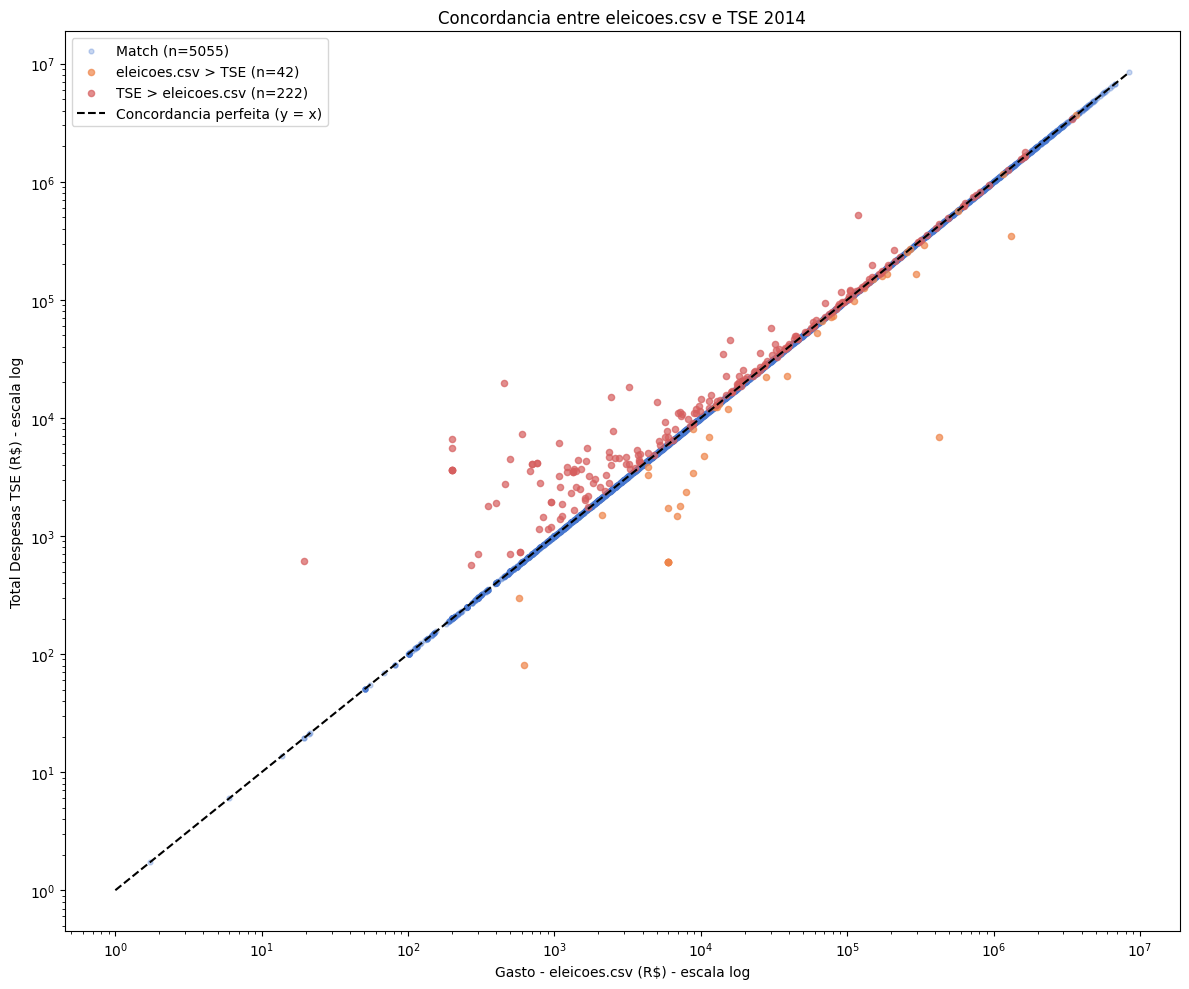

In [193]:
mask_match_plot = comparacao["Diferenca"] < 1
mask_div_el = (comparacao["Diferenca"] >= 1) & (
    comparacao["Gasto"] > comparacao["Total_Despesas_TSE"]
)
mask_div_ts = (comparacao["Diferenca"] >= 1) & (
    comparacao["Total_Despesas_TSE"] > comparacao["Gasto"]
)

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.scatter(
    comparacao.loc[mask_match_plot, "Gasto"] + 1,
    comparacao.loc[mask_match_plot, "Total_Despesas_TSE"] + 1,
    color=CORES[0],
    alpha=0.3,
    s=12,
    label=f"Match (n={mask_match_plot.sum()})",
)
ax.scatter(
    comparacao.loc[mask_div_el, "Gasto"] + 1,
    comparacao.loc[mask_div_el, "Total_Despesas_TSE"] + 1,
    color=CORES[1],
    alpha=0.7,
    s=20,
    label=f"eleicoes.csv > TSE (n={mask_div_el.sum()})",
)
ax.scatter(
    comparacao.loc[mask_div_ts, "Gasto"] + 1,
    comparacao.loc[mask_div_ts, "Total_Despesas_TSE"] + 1,
    color=CORES[3],
    alpha=0.7,
    s=20,
    label=f"TSE > eleicoes.csv (n={mask_div_ts.sum()})",
)

lim = max(comparacao["Gasto"].max(), comparacao["Total_Despesas_TSE"].max()) + 1
ax.plot([1, lim], [1, lim], "k--", label="Concordancia perfeita (y = x)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Gasto - eleicoes.csv (R$) - escala log")
ax.set_ylabel("Total Despesas TSE (R$) - escala log")
ax.set_title("Concordancia entre eleicoes.csv e TSE 2014")
ax.legend()
plt.tight_layout()
plt.savefig("assets/elections/validacao_gasto_tse.png")
plt.show()

**Observações:**
- pontos sobre a diagonal: valores identicos nas duas fontes
- pontos abaixo da diagonal: `eleicoes.csv` registra mais que o TSE
- pontos acima da diagonal: TSE registra mais que `eleicoes.csv`
- a concentracao de pontos sobre a diagonal confirma a consistencia dos dados
- as divergencias sao pontuais e nao comprometem a analise

o gráfico mostra que o merge entre as tabelas faz sentido e é o ano certo, já que o dataset do professor não falava de qual ano era.

#### <font color=slategray> 2.3.4 - Análise dos candidatos divergentes

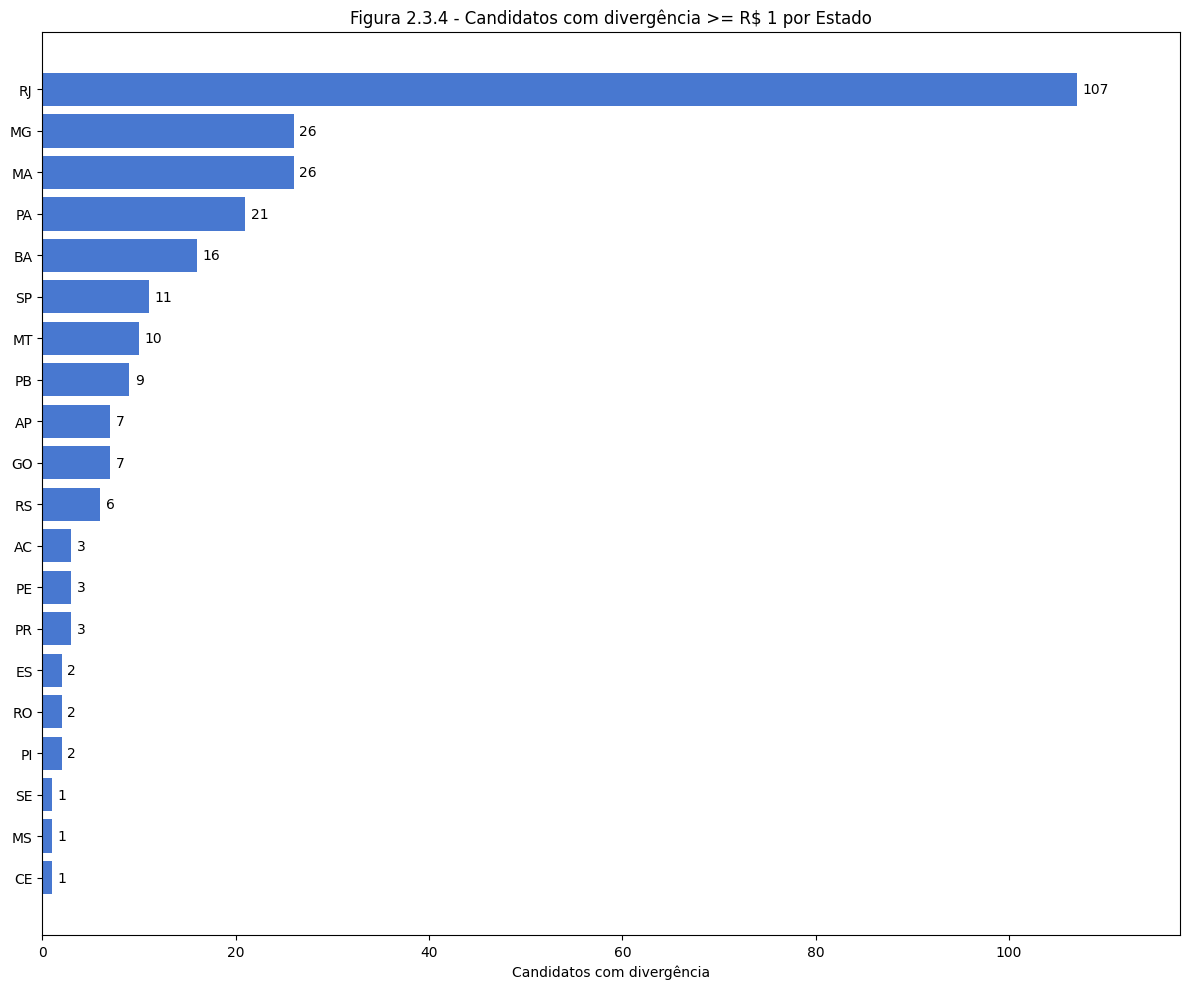

In [194]:
diverge = comparacao[mask_diverge].copy()


contagem = diverge.groupby("Estado").size().sort_values()

fig, ax = plt.subplots(figsize=FIGSIZE)

bars = ax.barh(contagem.index, contagem.values, color=CORES[0])
ax.bar_label(bars, padding=4)

ax.set_xlabel("Candidatos com divergência")
ax.set_title("Figura 2.3.4 - Candidatos com divergência >= R$ 1 por Estado")
ax.margins(x=0.1)
plt.tight_layout()
plt.savefig("assets/elections/divergentes_por_estado.png")
plt.show()

**Observações:**
- RJ concentra `~40%` das divergências (107 de 264)
- hipótese: o dataset do professor pode ter sido compilado a partir de uma versão anterior da prestação de contas do TSE
- as divergências não comprometem a análise: `Gasto` permanece como medida oficial do gasto declarado por candidato

## <font color=darkblue> 3 - Análise exploratória dos dados Brasil

antes de iniciar a análise, registro 3 decisões metodológicas que impactam os gráficos, tabelas e análises desta seção:

- coluna de gasto utilizada: utilizo `Gasto` do dataset do professor em vez de `Total_Despesas_TSE`. o professor não solicitou o enriquecimento e os dados do TSE podem gerar divergências expressivas dependendo do estado, como visto na seção 2.3. onde o RJ(quem diria) tem 107 divergências.
- exclusão de candidatos com gasto zero: removi todos os candidatos com `Gasto = 0`. nenhum candidato eleito teve gasto zero, eles representam uma parcela significativa do dataset e `esta análise é sobre comportamento de gastos`: candidatos que não gastaram nada não fazem parte do público que quero explorar
- ordem de análises: a análise vai ser primeiro com poucas análises do Brasil como um todo e depois vou escolher 3 estados para continuar com as exigencias do trabalho como foi pedido no pdf.

### <font color=steelblue> 3.1 - Visão geral do dataset

In [195]:
print("Tabela 3.1 — Estatísticas descritivas do dataset das Eleições de 2014")
display(
    eleicoes_enriquecido.describe()
    .drop(columns=["Numero Candidato", "CPF", "Votos"])
    .T.map(lambda x: f"{x:,.2f}")
)

Tabela 3.1 — Estatísticas descritivas do dataset das Eleições de 2014


,count,mean,std,min,25%,50%,75%,max
Gasto,"6,353.00","184,664.82","584,668.80",0.00,880.00,"5,804.26","46,569.29","8,464,594.14"
Qtd_Notas,"6,353.00",114.21,392.73,0.00,2.00,9.00,42.00,"6,413.00"
Total_Despesas_TSE,"5,392.00","217,794.87","628,857.96",0.14,"2,383.75","9,818.42","74,484.67","8,464,594.14"


### <font color=steelblue> 3.2 - Cáculo do bins

In [196]:
mask_com_gasto = eleicoes_enriquecido["Gasto"] > 0
gastos = eleicoes_enriquecido[mask_com_gasto]["Gasto"]

n_bins = int(np.sqrt(len(gastos)))

largura_linear = (gastos.max() - gastos.min()) / n_bins

resumo_bins = pd.DataFrame(
    {
        "Parâmetro": [
            "Candidatos com gasto > 0",
            "Número de bins (√n)",
            "Gasto mínimo",
            "Gasto máximo",
            "Largura de cada bin (linear)",
        ],
        "Valor": [
            f"{len(gastos):,}",
            f"{n_bins}",
            f"R$ {gastos.min():,.2f}",
            f"R$ {gastos.max():,.2f}",
            f"R$ {largura_linear:,.2f}",
        ],
    }
)

print("Tabela 3.2 - Parâmetros do histograma")
display(resumo_bins.set_index("Parâmetro"))

Tabela 3.2 - Parâmetros do histograma


,Valor
Parâmetro,
Candidatos com gasto > 0,"5,323"
Número de bins (√n),72
Gasto mínimo,R$ 0.72
Gasto máximo,"R$ 8,464,594.14"
Largura de cada bin (linear),"R$ 117,563.80"


**Observações:**
- o número de bins foi utilizado o cálculo ensinado em aula que era a raiz quadrada da quantidade de elementos
- n_bins = 72, ou seja, vou dividir meu intervalo em `72 partes`.
- cada bin vai ter aproximadamente `~R$115,000.00`

### <font color=steelblue> 3.3 - Distribuição do Gasto por Candidato

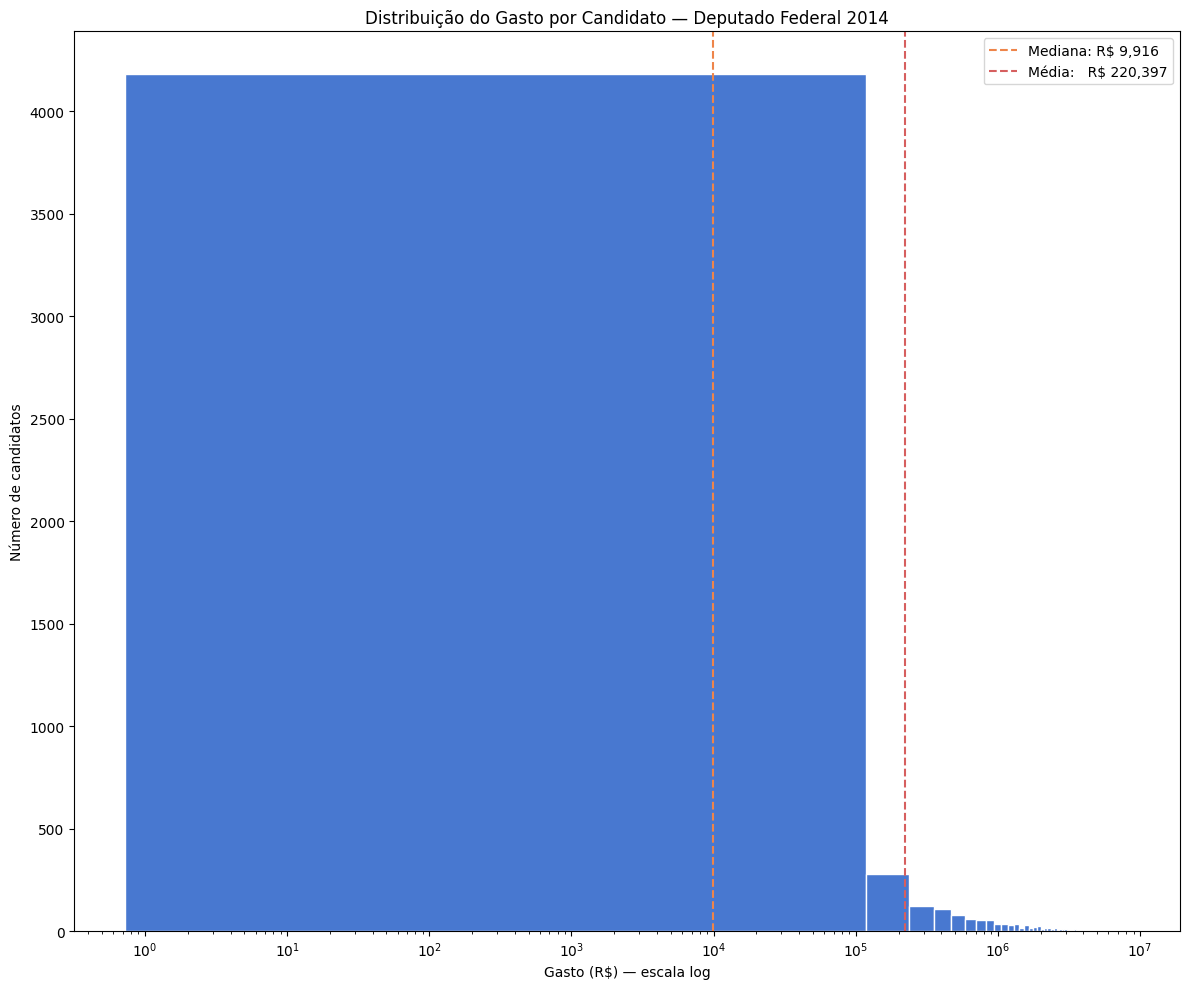

In [197]:
mask_com_gasto = eleicoes_enriquecido["Gasto"] > 0
gastos = eleicoes_enriquecido[mask_com_gasto]["Gasto"]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(gastos, bins=n_bins, color=CORES[0], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Gasto (R$) — escala log")
ax.set_ylabel("Número de candidatos")
ax.set_title("Distribuição do Gasto por Candidato — Deputado Federal 2014")
ax.axvline(
    gastos.median(),
    color=CORES[1],
    linestyle="--",
    label=f"Mediana: R$ {gastos.median():,.0f}",
)
ax.axvline(
    gastos.mean(),
    color=CORES[3],
    linestyle="--",
    label=f"Média:   R$ {gastos.mean():,.0f}",
)
ax.legend()
plt.tight_layout()
plt.savefig("assets/elections/distribuicao_gasto.png")
plt.show()

**Observações:**
- a distribuição é fortemente assimétrica à direita: a maioria dos candidatos gasta pouco, enquanto poucos concentram valores muito altos
- `mediana de R$ 9.916` contra `média de R$ 220.397`: o afastamento entre as duas medidas é sinal claro de assimetria e presença de valores extremos puxando a média para cima
- a cauda direita se estende até R$ 1M+, com poucos candidatos nessa faixa

### <font color=steelblue> 3.4 - Gasto por Estado

#### <font color=slategray> 3.4.1 - Gasto total por Estado

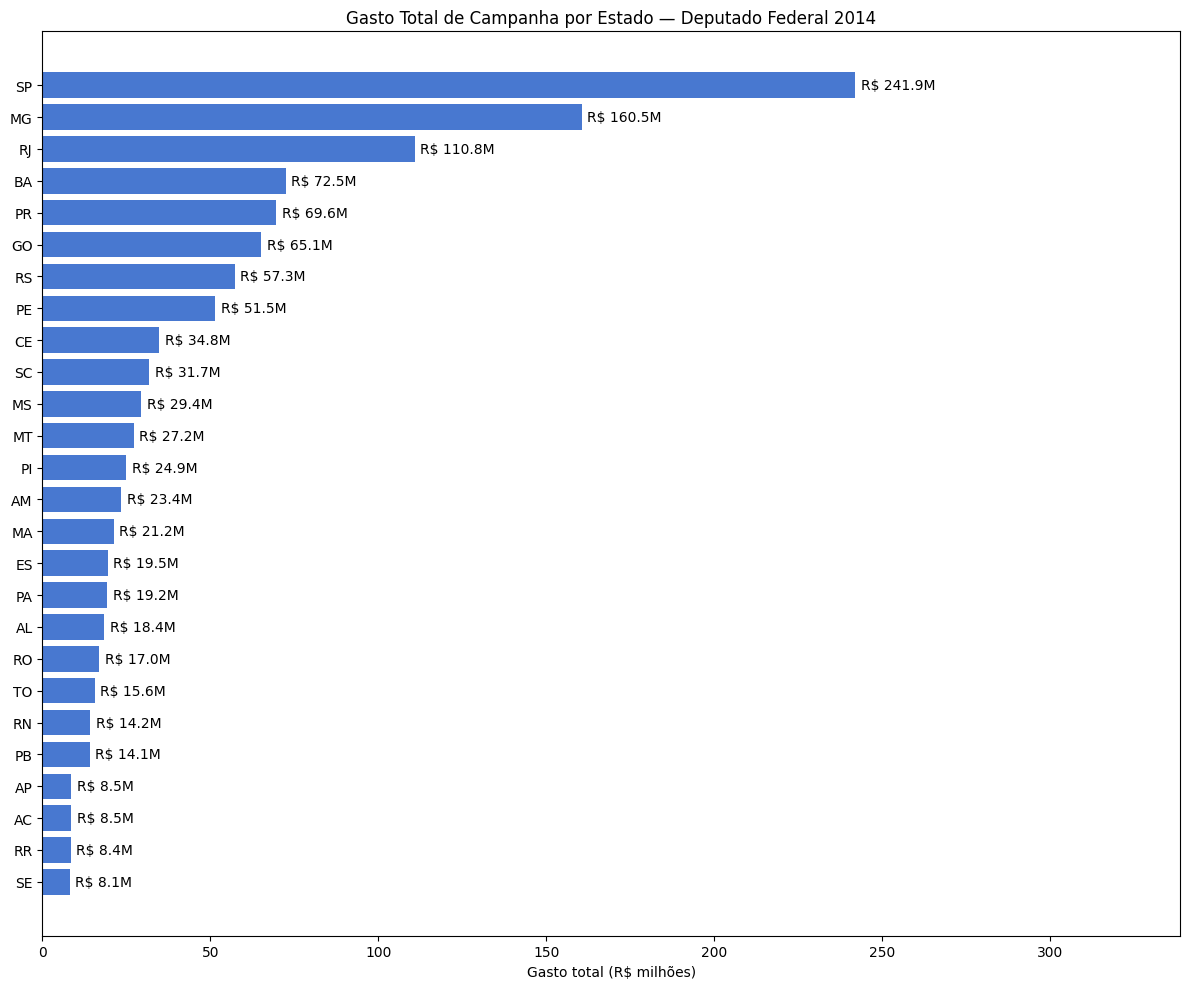

In [198]:
total_estado = (
    eleicoes_enriquecido[eleicoes_enriquecido["Gasto"] > 0]
    .groupby("Estado")["Gasto"]
    .sum()
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(total_estado.index, total_estado.values / 1e6, color=CORES[0])
ax.set_xlabel("Gasto total (R$ milhões)")
ax.set_title("Gasto Total de Campanha por Estado — Deputado Federal 2014")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4)
ax.set_xlim(0, total_estado.max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/gasto_total_estado.png")
plt.show()

**Observações:**
- SP, MG e RJ concentram os maiores volumes de gasto total


#### <font color=slategray> 3.4.2 - Gasto médio por Estado

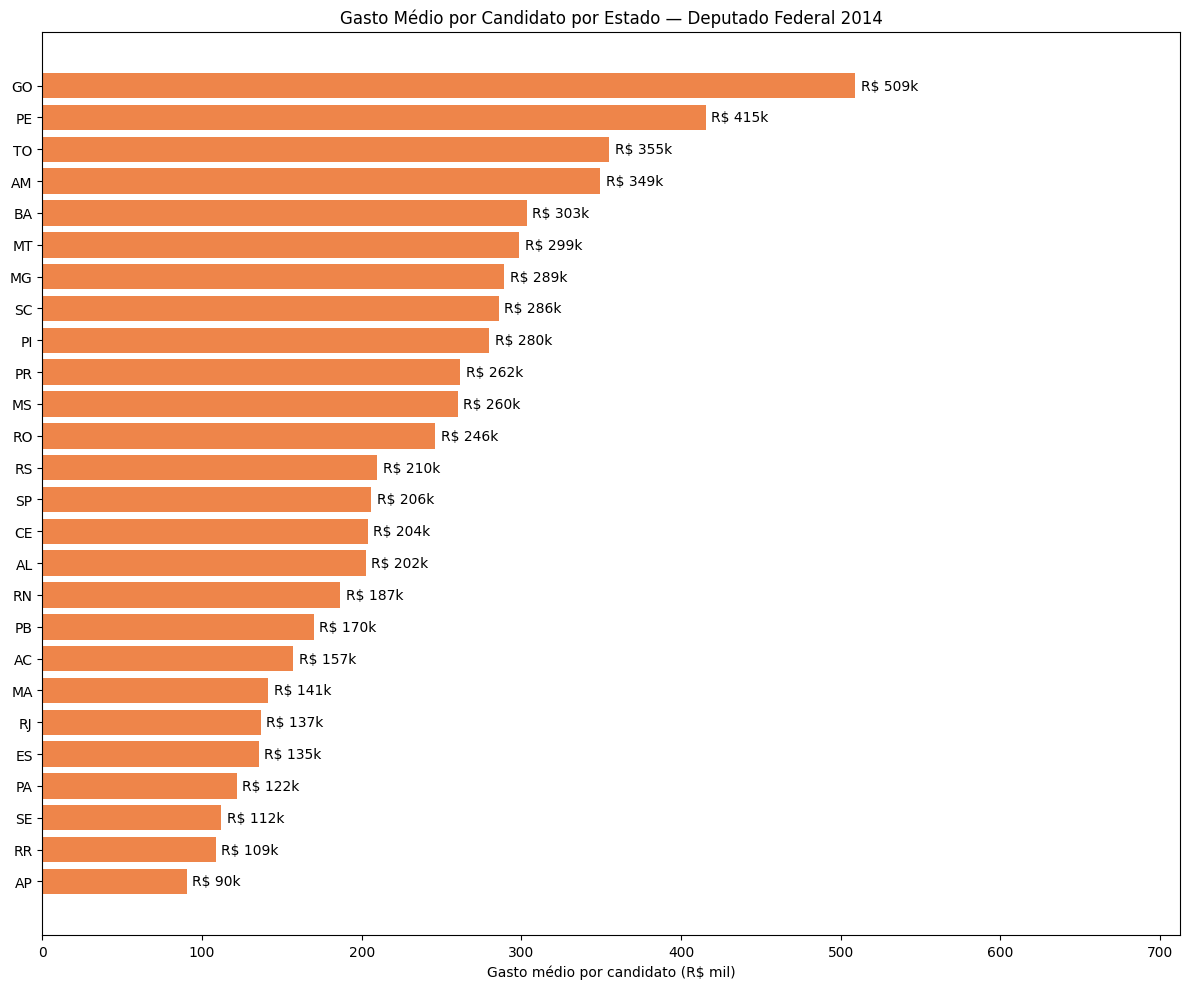

In [199]:
media_estado = (
    eleicoes_enriquecido[eleicoes_enriquecido["Gasto"] > 0]
    .groupby("Estado")["Gasto"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(media_estado.index, media_estado.values / 1e3, color=CORES[1])
ax.set_xlabel("Gasto médio por candidato (R$ mil)")
ax.set_title("Gasto Médio por Candidato por Estado — Deputado Federal 2014")
ax.bar_label(bars, fmt="R$ %.0fk", padding=4)
ax.set_xlim(0, media_estado.max() / 1e3 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/gasto_medio_estado.png")
plt.show()

**Observações:**
- o ranking de média difere do de total: estados menores como GO, TO e AM aparecem no topo, enquanto SP cai para posições intermediárias

### <font color=steelblue> 3.5 - Gasto por Partido (Top 10)

#### <font color=slategray> 3.5.1 - Total por Partido

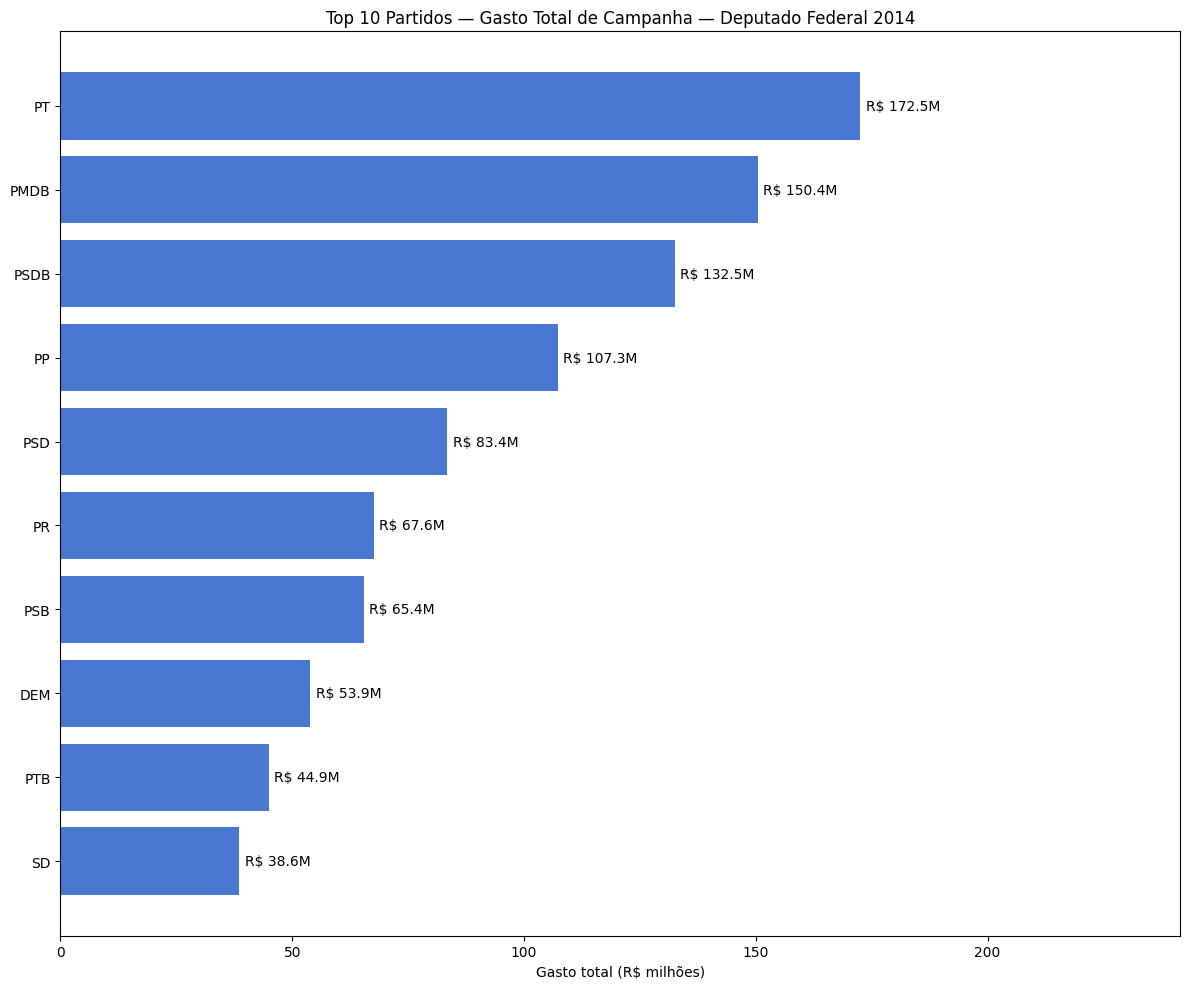

In [200]:
top10_total_partido = (
    eleicoes_enriquecido[eleicoes_enriquecido["Gasto"] > 0]
    .groupby("Partido")["Gasto"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(
    top10_total_partido.index, top10_total_partido.values / 1e6, color=CORES[0]
)
ax.set_xlabel("Gasto total (R$ milhões)")
ax.set_title("Top 10 Partidos — Gasto Total de Campanha — Deputado Federal 2014")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4)
ax.set_xlim(0, top10_total_partido.max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/gasto_total_partido.png")
plt.show()

**Observações:**
- PT, PMDB, PSDB e PP lideram o gasto total em 2014
- os quatro partidos tinham representação proporcional no Congresso e acesso ao fundo partidário, o que explica o volume maior de recursos disponíveis por candidatura

#### <font color=slategray> 3.5.2 - Média por Partido

o gasto médio por candidato revela quais partidos investem mais por cabeça. um partido pequeno que não apareceu no gráfico anterior pode entrar nesse por concentrar mais recursos em cada candidatura individual.

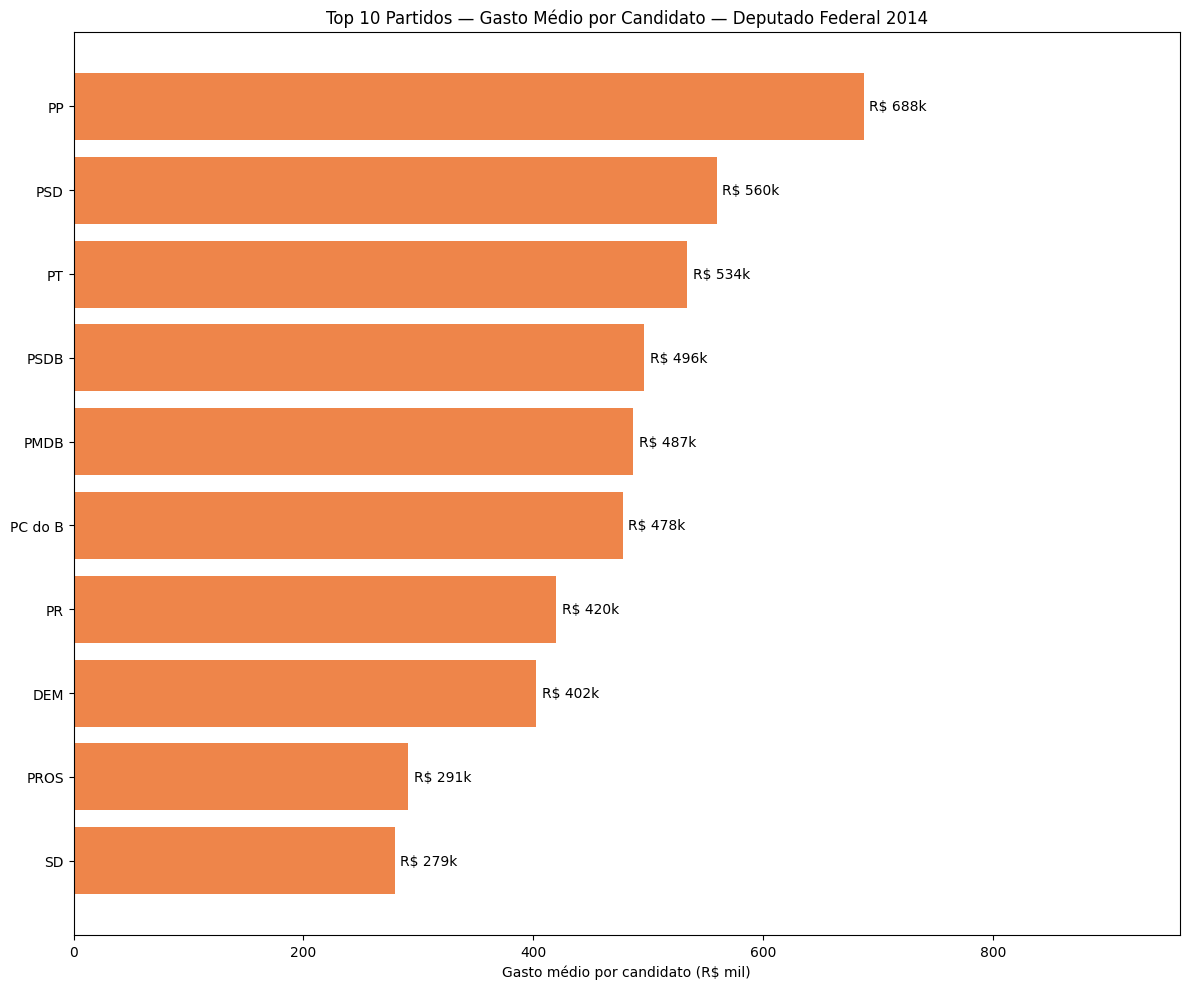

In [201]:
top10_media_partido = (
    eleicoes_enriquecido[eleicoes_enriquecido["Gasto"] > 0]
    .groupby("Partido")["Gasto"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(
    top10_media_partido.index, top10_media_partido.values / 1e3, color=CORES[1]
)
ax.set_xlabel("Gasto médio por candidato (R$ mil)")
ax.set_title("Top 10 Partidos — Gasto Médio por Candidato — Deputado Federal 2014")
ax.bar_label(bars, fmt="R$ %.0fk", padding=4)
ax.set_xlim(0, top10_media_partido.max() / 1e3 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/gasto_medio_partido.png")
plt.show()

**Observações:**
- partidos com poucos candidatos mas gasto alto por candidatura podem ter média elevada sem aparecer no ranking de total
- o indicador revela concentração de recursos por candidatura em vez de distribuição ampla

### <font color=steelblue> 3.6 - Gasto vs Votos por Situação Eleitoral

comparo gasto e votos de cada candidato colorindo por resultado eleitoral. linhas de referência verticais marcam o gasto mínimo, mediana, média e máximo dos eleitos. linhas horizontais marcam o mínimo de votos para eleição por média e por quociente partidário.

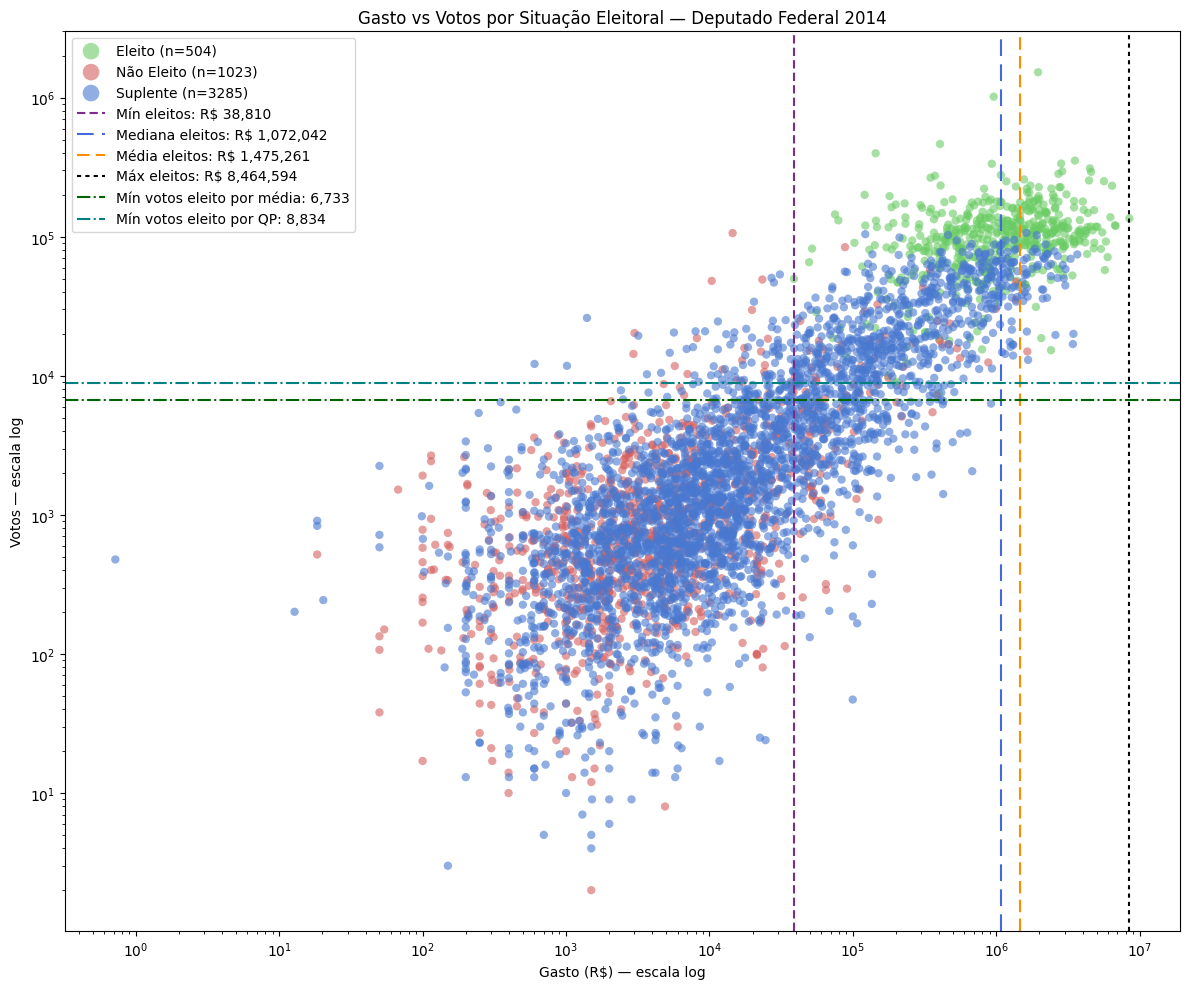

Tabela 3.6 - Gasto e Votos por Resultado Eleitoral


,N,Gasto Médio,Gasto Mediana,Gasto Mín,Gasto Máx,Votos Médios,Votos Mediana
Eleito,504,"R$ 1,475,261","R$ 1,072,042","R$ 38,810","R$ 8,464,594","113,917","102,866"
Suplente,"3,285","R$ 119,472","R$ 11,932",R$ 1,"R$ 3,672,371","8,211","1,722"
Não Eleito,"1,023","R$ 23,316","R$ 3,450",R$ 18,"R$ 1,646,192","2,454",736
Total,"4,812","R$ 241,033","R$ 11,840",R$ 1,"R$ 8,464,594","18,058","1,775"


In [202]:
plot_gasto_vs_votos(eleicoes_enriquecido)
tabela_gasto_vs_votos(eleicoes_enriquecido, "Tabela 3.6 - Gasto e Votos por Resultado Eleitoral")

**Observações:**
- candidatos eleitos concentram no quadrante superior direito: mais gasto e mais votos
- existe uma faixa de gasto mínimo dos eleitos: candidatos abaixo de R$ 38k raramente foram eleitos
- a correlação entre gasto e votos é positiva mas não determinística: há candidatos com alto gasto e poucos votos e vice versa
- suplentes e não eleitos se misturam bastante na faixa intermediária de gasto

### <font color=steelblue> 3.7 - Análise de Fornecedores

#### <font color=slategray> 3.7.1 - Gasto por Setor Econômico

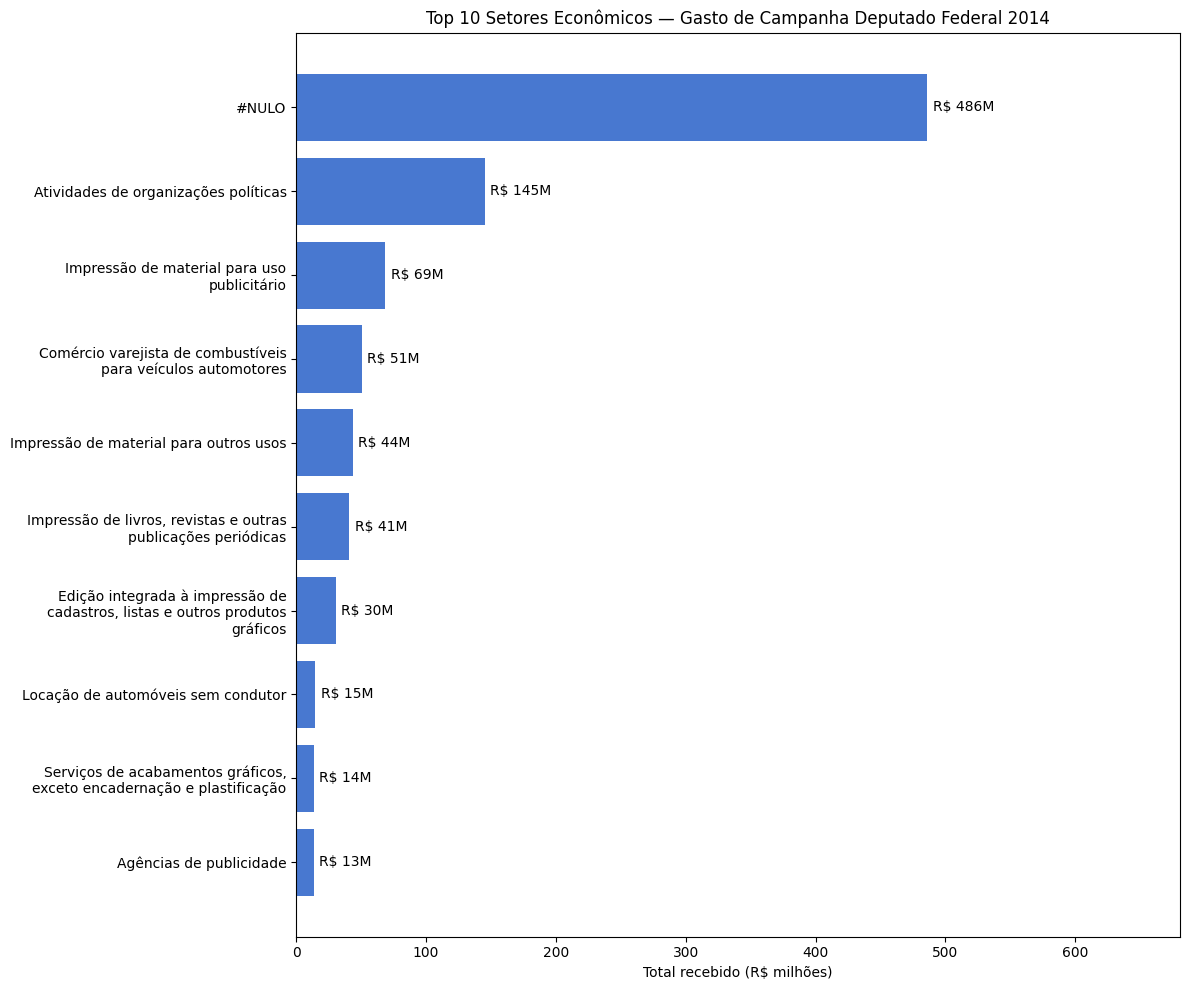

In [203]:
top_setores = (
    fornecedores_df.groupby("Setor")["Total_Recebido"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
labels_top_setores = [textwrap.fill(s, width=38) for s in top_setores.index]
bars = ax.barh(labels_top_setores, top_setores.values / 1e6, color=CORES[0])
ax.set_xlabel("Total recebido (R$ milhões)")
ax.set_title("Top 10 Setores Econômicos — Gasto de Campanha Deputado Federal 2014")
ax.bar_label(bars, fmt="R$ %.0fM", padding=4)
ax.set_xlim(0, top_setores.max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/fornecedores_setores.png")
plt.show()

**Observações:**
- `#NULO` lidera com R$ 486M (40.8% do total), quase metade das despesas não possui classificação setorial no TSE
- entre os setores classificados, organizações políticas e serviços gráficos dominam: impressão de material publicitário, livros e cadastros somados ultrapassam R$ 140M


#### <font color=slategray> 3.7.2 - Top fornecedores por valor recebido

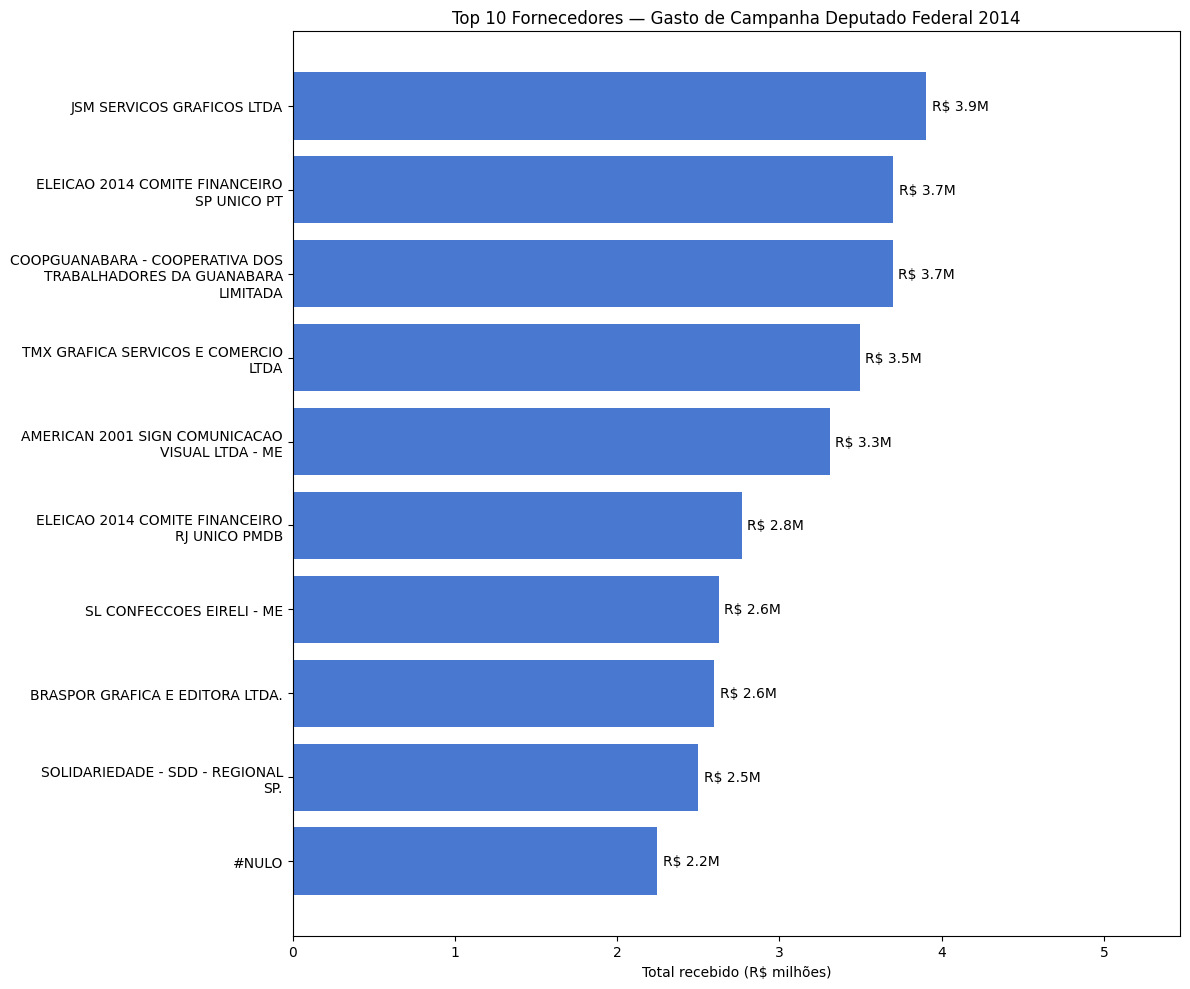

In [204]:
top_fornecedores = (
    fornecedores_df.groupby(["CNPJ Fornecedor", "Nome Fornecedor"])
    .agg(
        Total_Recebido=("Total_Recebido", "sum"),
        Qtd_Candidatos=("Numero Candidato", "nunique"),
    )
    .reset_index()
    .sort_values("Total_Recebido", ascending=False)
    .head(10)
    .sort_values("Total_Recebido")
)

fig, ax = plt.subplots(figsize=FIGSIZE)
nomes_top_fornecedores = top_fornecedores["Nome Fornecedor"].apply(lambda s: textwrap.fill(s, width=32))
bars = ax.barh(nomes_top_fornecedores, top_fornecedores["Total_Recebido"] / 1e6,
               color=CORES[0])
ax.set_xlabel("Total recebido (R$ milhões)")
ax.set_title("Top 10 Fornecedores — Gasto de Campanha Deputado Federal 2014")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4)
ax.set_xlim(0, top_fornecedores["Total_Recebido"].max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/fornecedores_top10.png")
plt.show()

**Observações:**
- gráficas e empresas de comunicação visual dominam o ranking, refletindo o peso do material impresso nas campanhas de 2014
- comitês eleitorais aparecem entre os maiores recebedores: são entidades criadas pelos próprios partidos para centralizar repasses entre candidatos
- os valores individuais são expressivos mas representam fração pequena do total de R$ 1,2 bilhão gasto, confirmando a pulverização vista no Pareto

## <font color=darkblue> 4 - Análise exploratória dos dados RJ

repito as mesmas análises da seção 3 filtrando os candidatos do Rio de Janeiro. o objetivo é identificar se o comportamento do estado segue o padrão nacional ou apresenta particularidades.

### <font color=steelblue> 4.1 - Visão geral do dataset

In [205]:
eleicoes_rj = eleicoes_enriquecido[eleicoes_enriquecido["Estado"] == "RJ"].copy()

print("Tabela 4.1 — Estatísticas descritivas do dataset das Eleições de 2014 — RJ")
display(
    eleicoes_rj.describe()
    .drop(columns=["Numero Candidato", "CPF", "Votos"])
    .T.map(lambda x: f"{x:,.2f}")
)

Tabela 4.1 — Estatísticas descritivas do dataset das Eleições de 2014 — RJ


,count,mean,std,min,25%,50%,75%,max
Gasto,"1,001.00","110,673.54","511,452.12",0.00,675.50,"3,324.00","17,138.50","6,788,349.32"
Qtd_Notas,"1,001.00",55.93,230.24,0.00,2.00,6.00,23.00,"4,693.00"
Total_Despesas_TSE,823.00,"134,750.06","561,208.85",0.14,"1,718.00","6,000.00","26,227.73","6,788,349.32"


**Observações:**
- RJ tem 1001 candidatos ao cargo de Deputado Federal, 810 (81%) com gasto registrado
- média de gasto de R$ 110.674 com desvio padrão de R$ 511.452, sinalizando alta dispersão
- gasto máximo de R$ 6,8M bem acima da média estadual, e votos chegando a 464.572

### <font color=steelblue> 4.2 - Cálculo do bins

In [206]:
mask_com_gasto_rj = eleicoes_rj["Gasto"] > 0
gastos_rj = eleicoes_rj[mask_com_gasto_rj]["Gasto"]

n_bins_rj = int(np.sqrt(len(gastos_rj)))

largura_linear_rj = (gastos_rj.max() - gastos_rj.min()) / n_bins_rj

resumo_bins_rj = pd.DataFrame(
    {
        "Parâmetro": [
            "Candidatos com gasto > 0",
            "Número de bins (√n)",
            "Gasto mínimo",
            "Gasto máximo",
            "Largura de cada bin (linear)",
        ],
        "Valor": [
            f"{len(gastos_rj):,}",
            f"{n_bins_rj}",
            f"R$ {gastos_rj.min():,.2f}",
            f"R$ {gastos_rj.max():,.2f}",
            f"R$ {largura_linear_rj:,.2f}",
        ],
    }
)

print("Tabela 4.2 - Parâmetros do histograma — RJ")
display(resumo_bins_rj.set_index("Parâmetro"))

Tabela 4.2 - Parâmetros do histograma — RJ


,Valor
Parâmetro,
Candidatos com gasto > 0,810
Número de bins (√n),28
Gasto mínimo,R$ 18.40
Gasto máximo,"R$ 6,788,349.32"
Largura de cada bin (linear),"R$ 242,440.39"


**Observações:**
- 810 candidatos com gasto maior que zero geram 28 bins pela regra da raiz quadrada
- amplitude de R$ 18 a R$ 6,8M cobre mais de 5 ordens de magnitude, tornando a largura linear de R$ 242k por bin inadequada para representar os dados
- a escala logarítmica no histograma é necessária para visualizar a distribuição com clareza

### <font color=steelblue> 4.3 - Distribuição do Gasto por Candidato

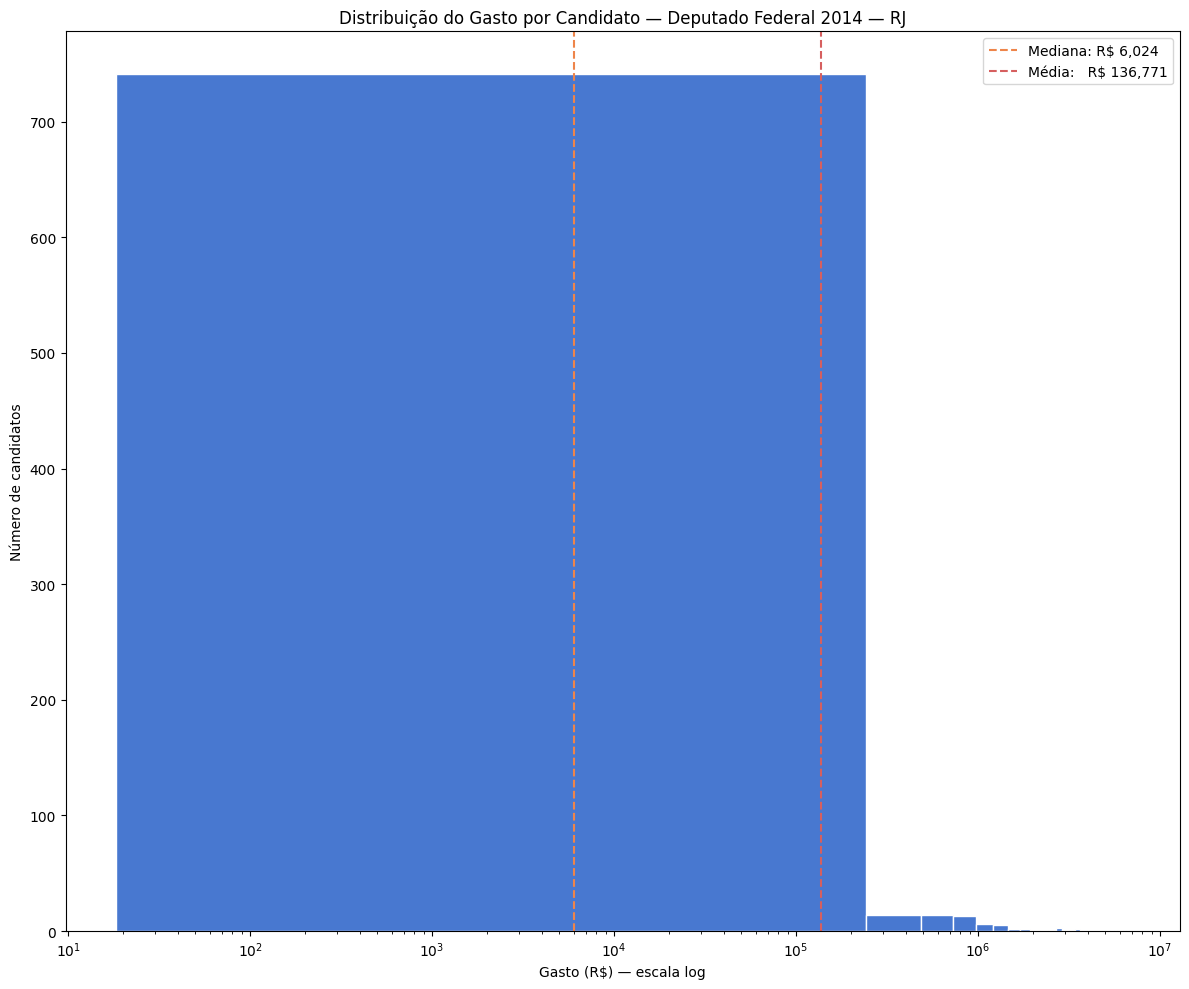

In [207]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(gastos_rj, bins=n_bins_rj, color=CORES[0], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Gasto (R$) — escala log")
ax.set_ylabel("Número de candidatos")
ax.set_title("Distribuição do Gasto por Candidato — Deputado Federal 2014 — RJ")
ax.axvline(
    gastos_rj.median(),
    color=CORES[1],
    linestyle="--",
    label=f"Mediana: R$ {gastos_rj.median():,.0f}",
)
ax.axvline(
    gastos_rj.mean(),
    color=CORES[3],
    linestyle="--",
    label=f"Média:   R$ {gastos_rj.mean():,.0f}",
)
ax.legend()
plt.tight_layout()
plt.savefig("assets/elections/rj_distribuicao_gasto.png")
plt.show()

**Observações:**
- distribuição fortemente assimétrica à direita, padrão similar ao nacional
- `mediana de R$ 6.024` contra `média de R$ 136.771`: afastamento de 22,7x entre as duas medidas, mais acentuado que o observado no Brasil como um todo
- a mediana do RJ é inferior à nacional (R$ 9.916), indicando que a maioria dos candidatos fluminenses gasta menos que a mediana do país
- a cauda direita se estende até R$ 6,8M, puxada por poucos candidatos de alto investimento

### <font color=steelblue> 4.4 - Distribuição dos Votos por Candidato

In [208]:
votos_rj = eleicoes_rj[eleicoes_rj["Votos"] > 0]["Votos"]

n_bins_votos_rj = int(np.sqrt(len(votos_rj)))

largura_linear_votos_rj = (votos_rj.max() - votos_rj.min()) / n_bins_votos_rj

resumo_bins_votos_rj = pd.DataFrame(
    {
        "Parâmetro": [
            "Candidatos com votos > 0",
            "Número de bins (√n)",
            "Votos mínimo",
            "Votos máximo",
            "Largura de cada bin (linear)",
        ],
        "Valor": [
            f"{len(votos_rj):,}",
            f"{n_bins_votos_rj}",
            f"{votos_rj.min():,.0f}",
            f"{votos_rj.max():,.0f}",
            f"{largura_linear_votos_rj:,.0f}",
        ],
    }
)

print("Tabela 4.4 - Parâmetros do histograma de votos — RJ")
display(resumo_bins_votos_rj.set_index("Parâmetro"))

Tabela 4.4 - Parâmetros do histograma de votos — RJ


,Valor
Parâmetro,
Candidatos com votos > 0,864
Número de bins (√n),29
Votos mínimo,5
Votos máximo,"464,572"
Largura de cada bin (linear),"16,020"


**Observações:**

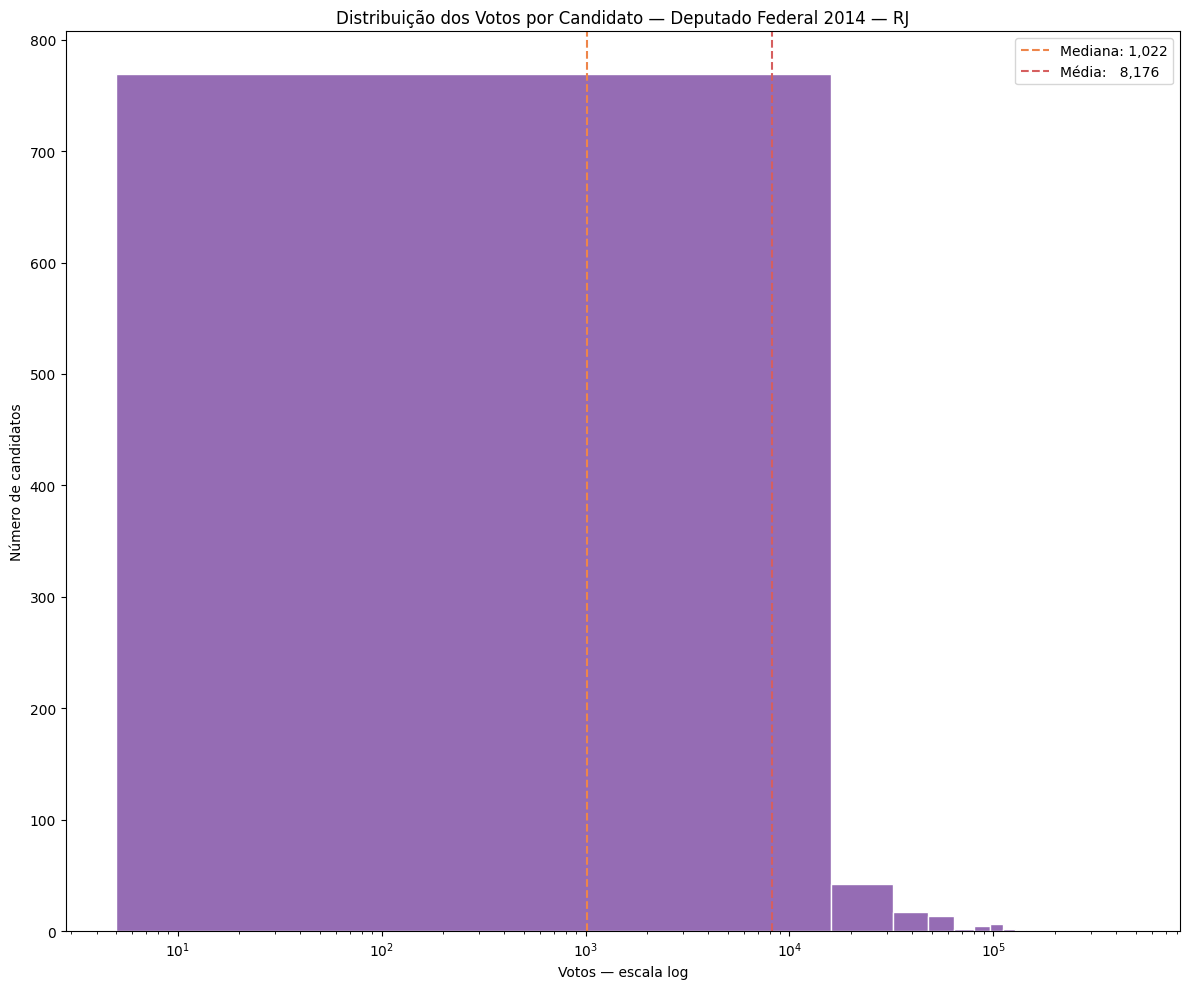

In [209]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(votos_rj, bins=n_bins_votos_rj, color=CORES[4], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Votos — escala log")
ax.set_ylabel("Número de candidatos")
ax.set_title("Distribuição dos Votos por Candidato — Deputado Federal 2014 — RJ")
ax.axvline(
    votos_rj.median(),
    color=CORES[1],
    linestyle="--",
    label=f"Mediana: {votos_rj.median():,.0f}",
)
ax.axvline(
    votos_rj.mean(),
    color=CORES[3],
    linestyle="--",
    label=f"Média:   {votos_rj.mean():,.0f}",
)
ax.legend()
plt.tight_layout()
plt.savefig("assets/elections/rj_distribuicao_votos.png")
plt.show()

**Observações:**
- distribuição de votos fortemente assimétrica à direita: a maioria dos candidatos obteve poucos votos, enquanto poucos concentraram dezenas ou centenas de milhares
- `mediana de 1.022 votos` contra `média de 8.176`: afastamento de 8x, indicando forte influência dos candidatos mais votados na média
- a cauda direita se estende até 464.572 votos, puxada pelos candidatos eleitos com alta votação

### <font color=steelblue> 4.5 - Gasto por Partido

#### <font color=slategray> 4.5.1 - Gasto total por Partido

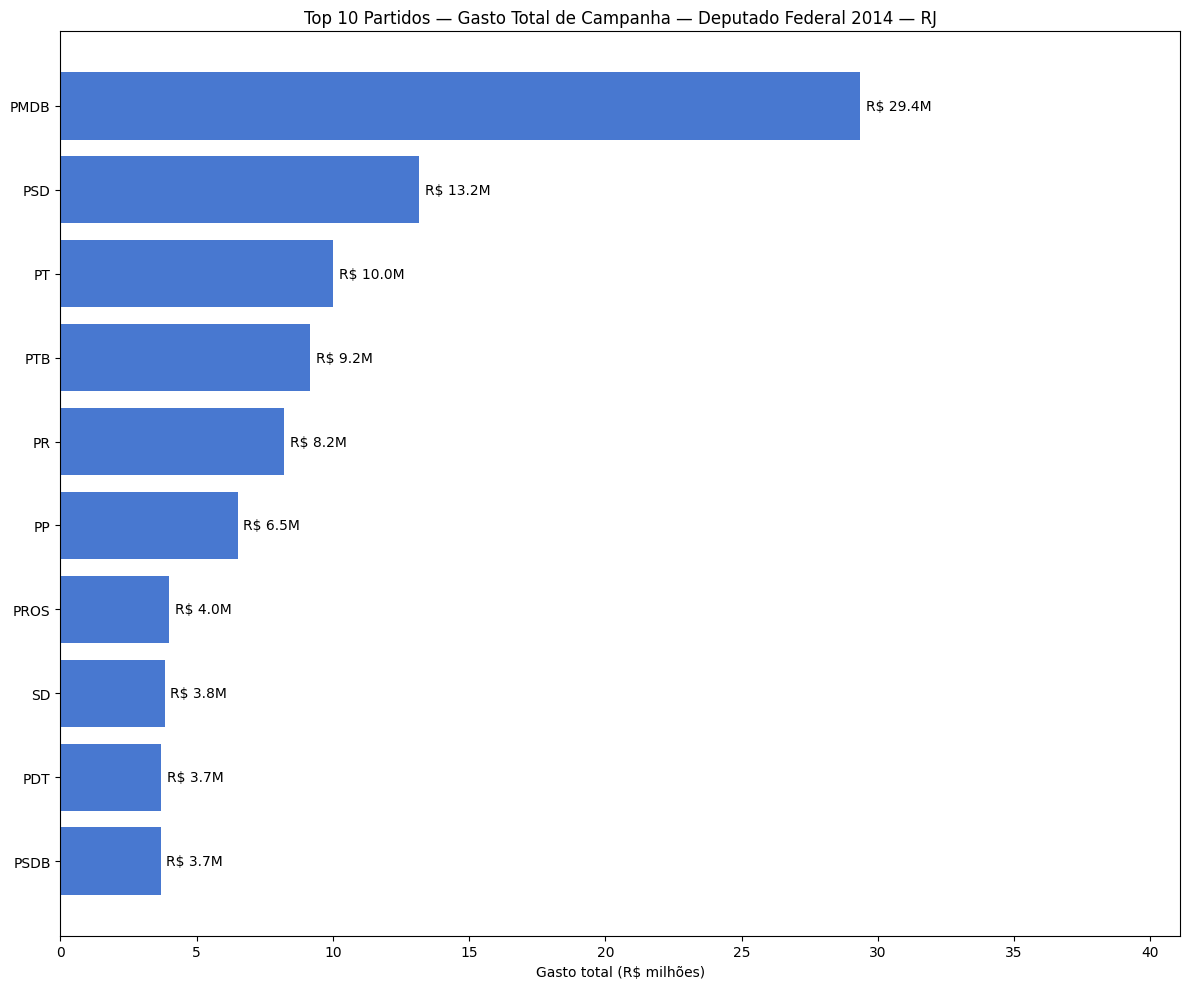

In [210]:
top_total_partido_rj = (
    eleicoes_rj[eleicoes_rj["Gasto"] > 0]
    .groupby("Partido")["Gasto"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(
    top_total_partido_rj.index, top_total_partido_rj.values / 1e6, color=CORES[0]
)
ax.set_xlabel("Gasto total (R$ milhões)")
ax.set_title("Top 10 Partidos — Gasto Total de Campanha — Deputado Federal 2014 — RJ")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4)
ax.set_xlim(0, top_total_partido_rj.max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/rj_gasto_total_partido.png")
plt.show()

**Observações:**
- PMDB lidera com R$ 29,4M, mais do que o dobro do segundo colocado PSD (R$ 13,2M)
- PT, PTB e PR completam o top 5, concentrando juntos com o PMDB a maior parte do gasto total do estado

#### <font color=slategray> 4.5.2 - Gasto médio por Partido

o gasto médio por candidato revela quais partidos investem mais por cabeça dentro do RJ. partidos com poucos candidatos e alto gasto médio se destacam diferente do ranking de total.

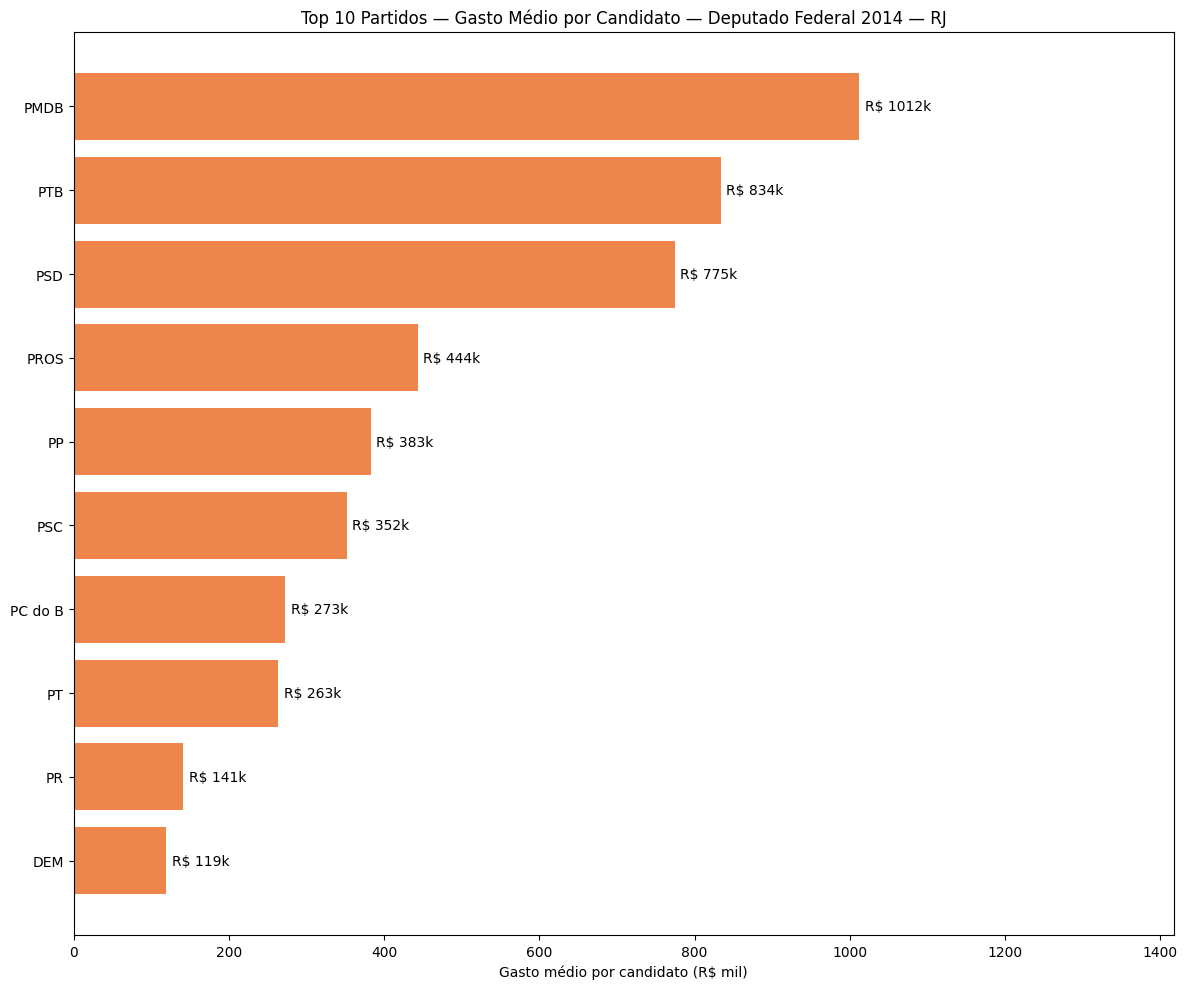

In [211]:
top_media_partido_rj = (
    eleicoes_rj[eleicoes_rj["Gasto"] > 0]
    .groupby("Partido")["Gasto"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(
    top_media_partido_rj.index, top_media_partido_rj.values / 1e3, color=CORES[1]
)
ax.set_xlabel("Gasto médio por candidato (R$ mil)")
ax.set_title("Top 10 Partidos — Gasto Médio por Candidato — Deputado Federal 2014 — RJ")
ax.bar_label(bars, fmt="R$ %.0fk", padding=4)
ax.set_xlim(0, top_media_partido_rj.max() / 1e3 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/rj_gasto_medio_partido.png")
plt.show()

**Observações:**
- PMDB mantém a liderança também na média com R$ 1,0M por candidato
- PTB aparece em segundo com R$ 834k, acima do PT (R$ 263k): o partido lançou poucos candidatos mas com alto investimento individual
- a inversão em relação ao ranking de total mostra que volume e concentração por candidatura são dinâmicas distintas

### <font color=steelblue> 4.6 - Gasto vs Votos por Situação Eleitoral

uso a mesma função da seção 3.6 passando o filtro de estado para comparar gasto e votos dos candidatos do RJ por resultado eleitoral.

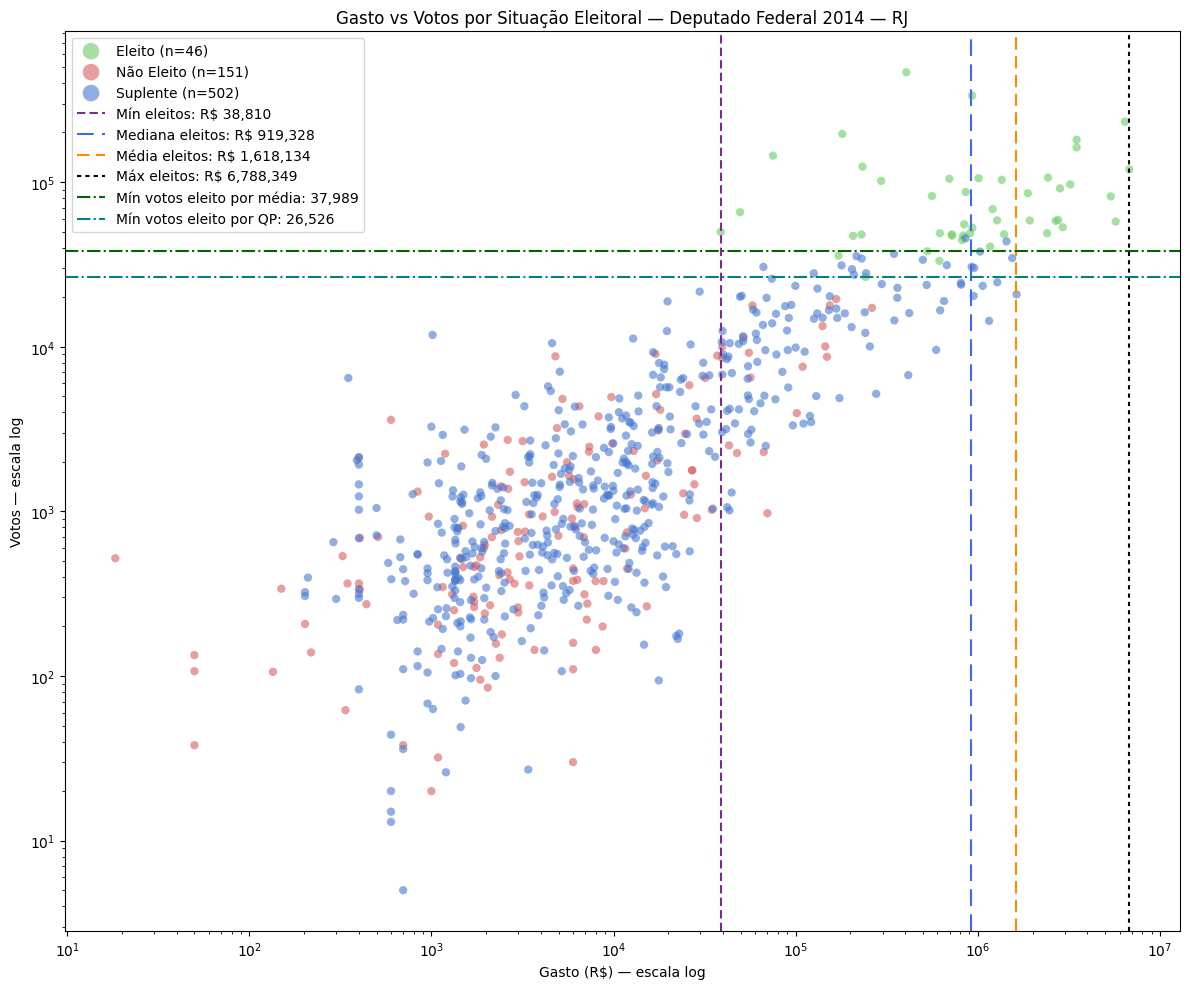

Tabela 4.6 - Gasto e Votos por Resultado Eleitoral — RJ


,N,Gasto Médio,Gasto Mediana,Gasto Mín,Gasto Máx,Votos Médios,Votos Mediana
Eleito,46,"R$ 1,618,134","R$ 919,328","R$ 38,810","R$ 6,788,349","93,354","58,680"
Suplente,502,"R$ 63,197","R$ 7,561",R$ 202,"R$ 1,633,154","4,557","1,250"
Não Eleito,151,"R$ 17,496","R$ 4,753",R$ 18,"R$ 262,585","2,258",769
Total,699,"R$ 155,652","R$ 7,368",R$ 18,"R$ 6,788,349","9,904","1,264"


In [212]:
plot_gasto_vs_votos(eleicoes_enriquecido, estados=["RJ"])
tabela_gasto_vs_votos(eleicoes_enriquecido, "Tabela 4.6 - Gasto e Votos por Resultado Eleitoral — RJ", estados=["RJ"])

**Observações:**
- eleitos do RJ se concentram no quadrante superior direito com mediana de gasto de R$ 919k e mediana de votos de 58.680
- a separação entre grupos é nítida: não eleitos têm mediana de gasto de R$ 1.718, mais de 500x menor que a dos eleitos
- o padrão de cauda longa se mantém: há candidatos com alto gasto e poucos votos, e alguns eleitos com gasto relativamente baixo

#### <font color=slategray> 4.6.1 - Coeficiente de Pearson e Matriz de Correlação

In [213]:
dados_rj = eleicoes_rj[["Gasto", "Votos"]].dropna()
dados_rj = dados_rj[(dados_rj["Gasto"] > 0) & (dados_rj["Votos"] > 0)]

r_rj, p_rj = pearsonr(dados_rj["Gasto"], dados_rj["Votos"])

resultado_rj = pd.Series(
    {"Coeficiente de Pearson (r)": round(r_rj, 3), "p-valor": round(p_rj, 4)},
    name="Gasto × Votos — RJ"
)
print("Tabela 4.6.1 — Correlação de Pearson — RJ")
display(resultado_rj.to_frame())

Tabela 4.6.1 — Correlação de Pearson — RJ


,Gasto × Votos — RJ
Coeficiente de Pearson (r),0.556
p-valor,0.000


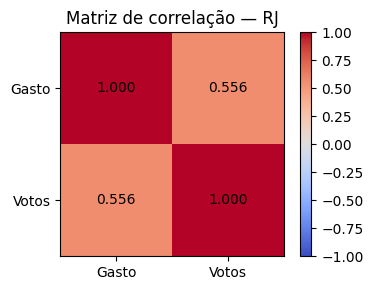

In [214]:
corr_rj = dados_rj[["Gasto", "Votos"]].corr()

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr_rj, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_rj.columns)), corr_rj.columns)
ax.set_yticks(range(len(corr_rj.index)), corr_rj.index)
for i in range(len(corr_rj)):
    for j in range(len(corr_rj.columns)):
        ax.text(j, i, f"{corr_rj.iloc[i, j]:.3f}", ha="center", va="center", color="black")
ax.set_title("Matriz de correlação — RJ")
plt.tight_layout()
plt.savefig("assets/elections/rj_matriz_correlacao.png")
plt.show()

**Observações:**
- o coeficiente de Pearson entre gasto e votos no RJ é de `r = 0,556`, indicando correlação moderada positiva
- candidatos que gastam mais tendem a receber mais votos, mas a relação não é determinística: a nuvem de pontos mostra dispersão considerável
- o p-valor indica que a correlação é estatisticamente significativa

### <font color=steelblue> 4.7 - Análise de Fornecedores

#### <font color=slategray> 4.7.1 - Gasto por Setor Econômico

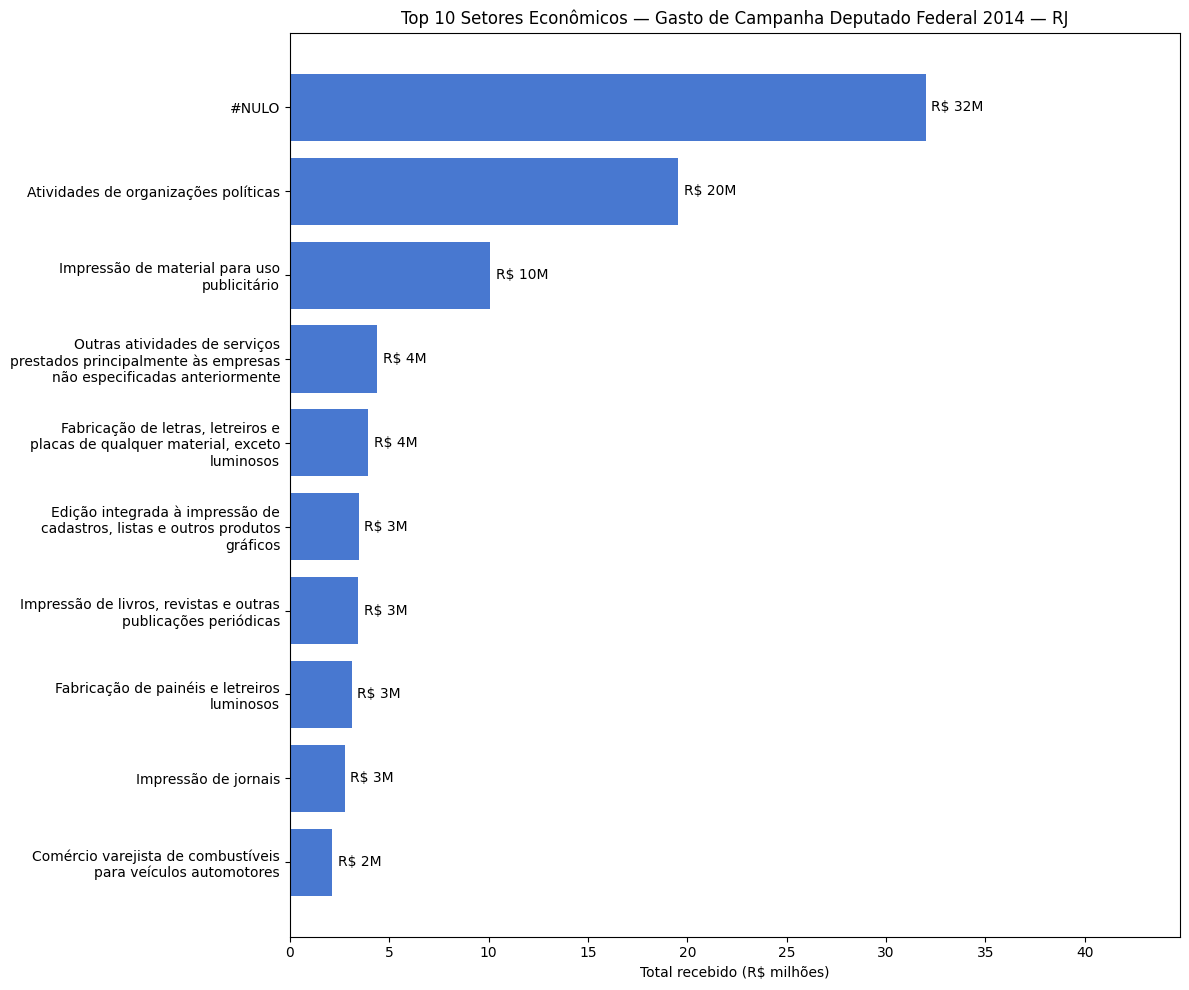

In [215]:
fornecedores_rj = fornecedores_df[fornecedores_df["Estado"] == "RJ"]

top_setores_rj = (
    fornecedores_rj.groupby("Setor")["Total_Recebido"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
labels_top_setores_rj = [textwrap.fill(s, width=38) for s in top_setores_rj.index]
bars = ax.barh(labels_top_setores_rj, top_setores_rj.values / 1e6, color=CORES[0])
ax.set_xlabel("Total recebido (R$ milhões)")
ax.set_title("Top 10 Setores Econômicos — Gasto de Campanha Deputado Federal 2014 — RJ")
ax.bar_label(bars, fmt="R$ %.0fM", padding=4)
ax.set_xlim(0, top_setores_rj.max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/rj_fornecedores_setores.png")
plt.show()

**Observações:**
- `#NULO` lidera com R$ 32M (28,8% do total), proporção menor que no nacional (40,8%), indicando melhor cobertura de classificação setorial no RJ
- organizações políticas em segundo com R$ 19,5M (17,6%), acima da proporção nacional, sugerindo maior centralização de repasses via comitês partidários no estado
- impressão de material publicitário em terceiro com R$ 10,1M (9,1%), padrão consistente com o nacional

#### <font color=slategray> 4.7.2 - Top fornecedores por valor recebido

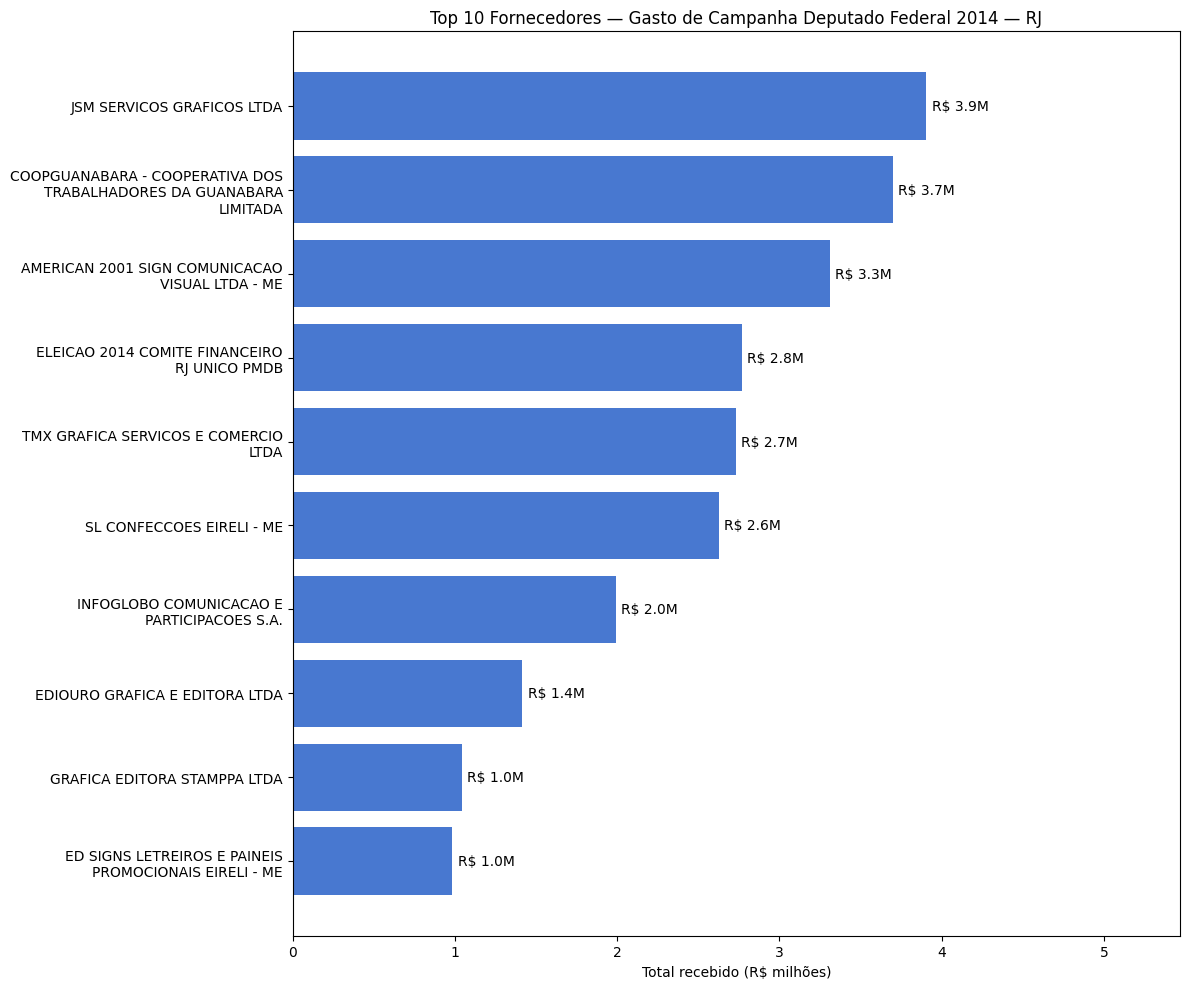

In [216]:
top_fornecedores_rj = (
    fornecedores_rj.groupby(["CNPJ Fornecedor", "Nome Fornecedor"])
    .agg(
        Total_Recebido=("Total_Recebido", "sum"),
        Qtd_Candidatos=("Numero Candidato", "nunique"),
    )
    .reset_index()
    .sort_values("Total_Recebido", ascending=False)
    .head(10)
    .sort_values("Total_Recebido")
)

fig, ax = plt.subplots(figsize=FIGSIZE)
nomes_top_fornecedores_rj = top_fornecedores_rj["Nome Fornecedor"].apply(lambda s: textwrap.fill(s, width=32))
bars = ax.barh(
    nomes_top_fornecedores_rj,
    top_fornecedores_rj["Total_Recebido"] / 1e6,
    color=CORES[0],
)
ax.set_xlabel("Total recebido (R$ milhões)")
ax.set_title("Top 10 Fornecedores — Gasto de Campanha Deputado Federal 2014 — RJ")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4)
ax.set_xlim(0, top_fornecedores_rj["Total_Recebido"].max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/rj_fornecedores_top10.png")
plt.show()

**Observações:**
- JSM Serviços Gráficos lidera com R$ 3,9M atendendo 30 candidatos, confirmando sua posição de maior fornecedor também no recorte do RJ
- COOPGUANABARA se destaca com R$ 3,7M concentrados em 1 único candidato, a maior concentração de recursos individuais do top 10
- o Comitê Financeiro do PMDB aparece com R$ 2,8M distribuídos entre 388 candidaturas, o maior número de beneficiários do ranking


## <font color=darkblue> 5 - Análise exploratória dos dados GO

repito as mesmas análises filtrando os candidatos de Goiás. o estado tem porte intermediário e apresenta algumas particularidades em relação ao padrão nacional e ao RJ.

### <font color=steelblue> 5.1 - Visão geral do dataset

In [217]:
eleicoes_go = eleicoes_enriquecido[eleicoes_enriquecido["Estado"] == "GO"].copy()

print("Tabela 5.1 — Estatísticas descritivas do dataset das Eleições de 2014 — GO")
display(
    eleicoes_go.describe()
    .drop(columns=["Numero Candidato", "CPF", "Votos"])
    .T.map(lambda x: f"{x:,.2f}")
)

Tabela 5.1 — Estatísticas descritivas do dataset das Eleições de 2014 — GO


,count,mean,std,min,25%,50%,75%,max
Gasto,144.00,"452,396.19","1,091,612.50",0.00,617.67,"2,526.72","45,404.48","5,812,787.78"
Qtd_Notas,144.00,350.24,907.75,0.00,2.00,4.00,54.00,"5,379.00"
Total_Despesas_TSE,126.00,"517,113.85","1,153,032.66",80.00,"1,000.00","4,120.51","108,437.01","5,812,787.78"


**Observações:**
- GO tem 144 candidatos ao cargo de Deputado Federal, 128 (89%) com gasto registrado
- média de gasto de R$ 452.396 com desvio padrão de R$ 1.091.612, dispersão muito alta em relação à própria média
- votos máximos de 274.625, compatível com o eleitorado de porte intermediário do estado

### <font color=steelblue> 5.2 - Cálculo do bins

In [218]:
mask_com_gasto_go = eleicoes_go["Gasto"] > 0
gastos_go = eleicoes_go[mask_com_gasto_go]["Gasto"]

n_bins_go = int(np.sqrt(len(gastos_go)))

largura_linear_go = (gastos_go.max() - gastos_go.min()) / n_bins_go

resumo_bins_go = pd.DataFrame(
    {
        "Parâmetro": [
            "Candidatos com gasto > 0",
            "Número de bins (√n)",
            "Gasto mínimo",
            "Gasto máximo",
            "Largura de cada bin (linear)",
        ],
        "Valor": [
            f"{len(gastos_go):,}",
            f"{n_bins_go}",
            f"R$ {gastos_go.min():,.2f}",
            f"R$ {gastos_go.max():,.2f}",
            f"R$ {largura_linear_go:,.2f}",
        ],
    }
)

print("Tabela 5.2 - Parâmetros do histograma — GO")
display(resumo_bins_go.set_index("Parâmetro"))

Tabela 5.2 - Parâmetros do histograma — GO


,Valor
Parâmetro,
Candidatos com gasto > 0,128
Número de bins (√n),11
Gasto mínimo,R$ 80.00
Gasto máximo,"R$ 5,812,787.78"
Largura de cada bin (linear),"R$ 528,427.98"


**Observações:**
- 128 candidatos com gasto geram 11 bins pela regra da raiz quadrada
- amplitude de R$ 80 a R$ 5,8M resulta em largura linear de R$ 528k por bin, inviável para representar a distribuição sem escala logarítmica

### <font color=steelblue> 5.3 - Distribuição do Gasto por Candidato

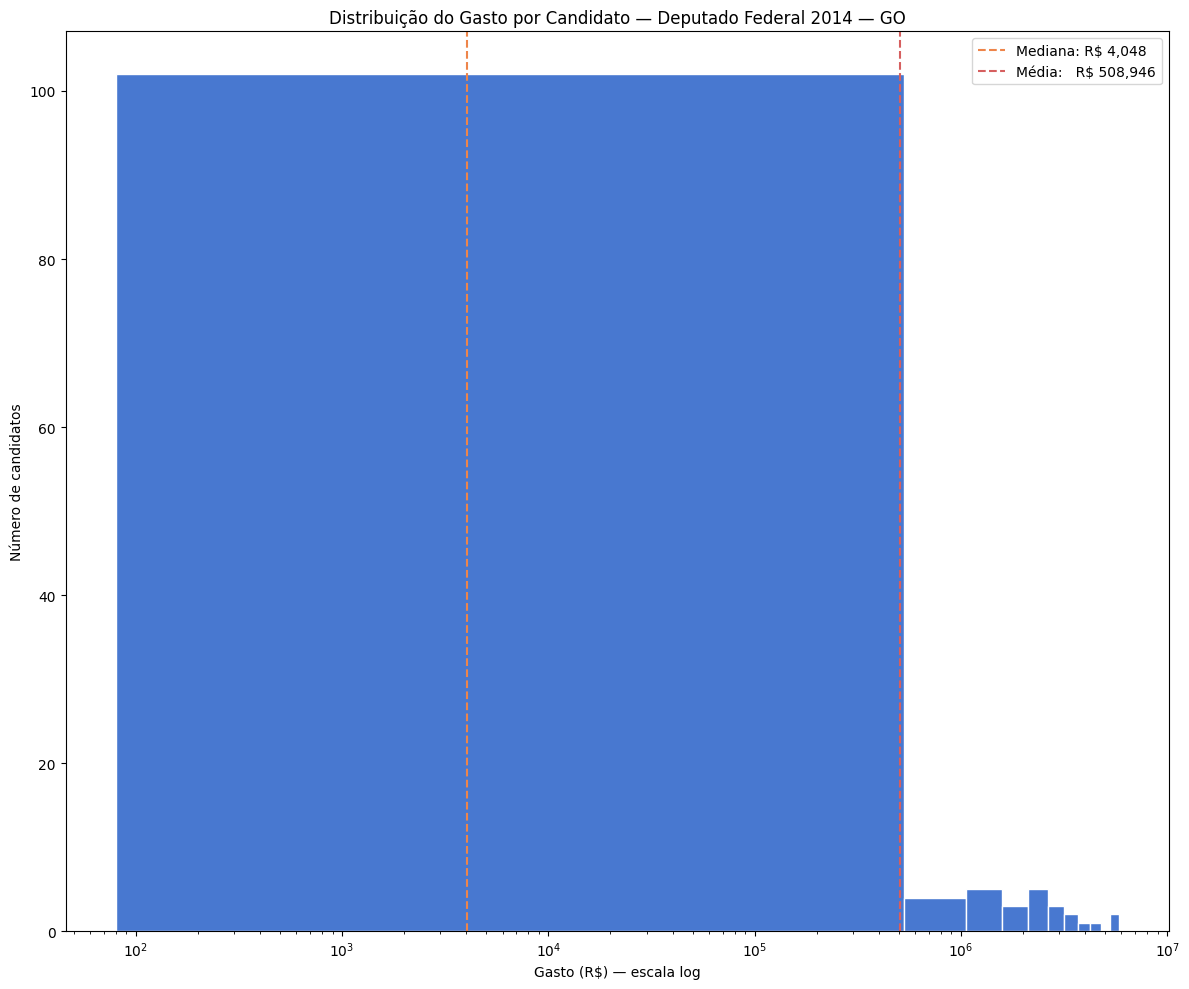

In [219]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(gastos_go, bins=n_bins_go, color=CORES[0], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Gasto (R$) — escala log")
ax.set_ylabel("Número de candidatos")
ax.set_title("Distribuição do Gasto por Candidato — Deputado Federal 2014 — GO")
ax.axvline(
    gastos_go.median(),
    color=CORES[1],
    linestyle="--",
    label=f"Mediana: R$ {gastos_go.median():,.0f}",
)
ax.axvline(
    gastos_go.mean(),
    color=CORES[3],
    linestyle="--",
    label=f"Média:   R$ {gastos_go.mean():,.0f}",
)
ax.legend()
plt.tight_layout()
plt.savefig("assets/elections/go_distribuicao_gasto.png")
plt.show()

**Observações:**
- distribuição fortemente assimétrica à direita, padrão mantido nos três recortes analisados
- `mediana de R$ 4.048` contra `média de R$ 508.946`: afastamento de 125,7x, o maior entre os recortes analisados e bem acima do nacional
- a mediana do GO (R$ 4.048) é inferior à nacional (R$ 9.916), indicando que a maioria dos candidatos goianos gasta pouco, enquanto poucos concentram valores extremamente altos
- a combinação de mediana baixa e média altíssima aponta para outliers mais extremos que no RJ

### <font color=steelblue> 5.4 - Distribuição dos Votos por Candidato

In [220]:
votos_go = eleicoes_go[eleicoes_go["Votos"] > 0]["Votos"]

n_bins_votos_go = int(np.sqrt(len(votos_go)))

largura_linear_votos_go = (votos_go.max() - votos_go.min()) / n_bins_votos_go

resumo_bins_votos_go = pd.DataFrame(
    {
        "Parâmetro": [
            "Candidatos com votos > 0",
            "Número de bins (√n)",
            "Votos mínimo",
            "Votos máximo",
            "Largura de cada bin (linear)",
        ],
        "Valor": [
            f"{len(votos_go):,}",
            f"{n_bins_votos_go}",
            f"{votos_go.min():,.0f}",
            f"{votos_go.max():,.0f}",
            f"{largura_linear_votos_go:,.0f}",
        ],
    }
)

print("Tabela 5.4 - Parâmetros do histograma de votos — GO")
display(resumo_bins_votos_go.set_index("Parâmetro"))

Tabela 5.4 - Parâmetros do histograma de votos — GO


,Valor
Parâmetro,
Candidatos com votos > 0,93
Número de bins (√n),9
Votos mínimo,35
Votos máximo,"274,625"
Largura de cada bin (linear),"30,510"


**Observações:**

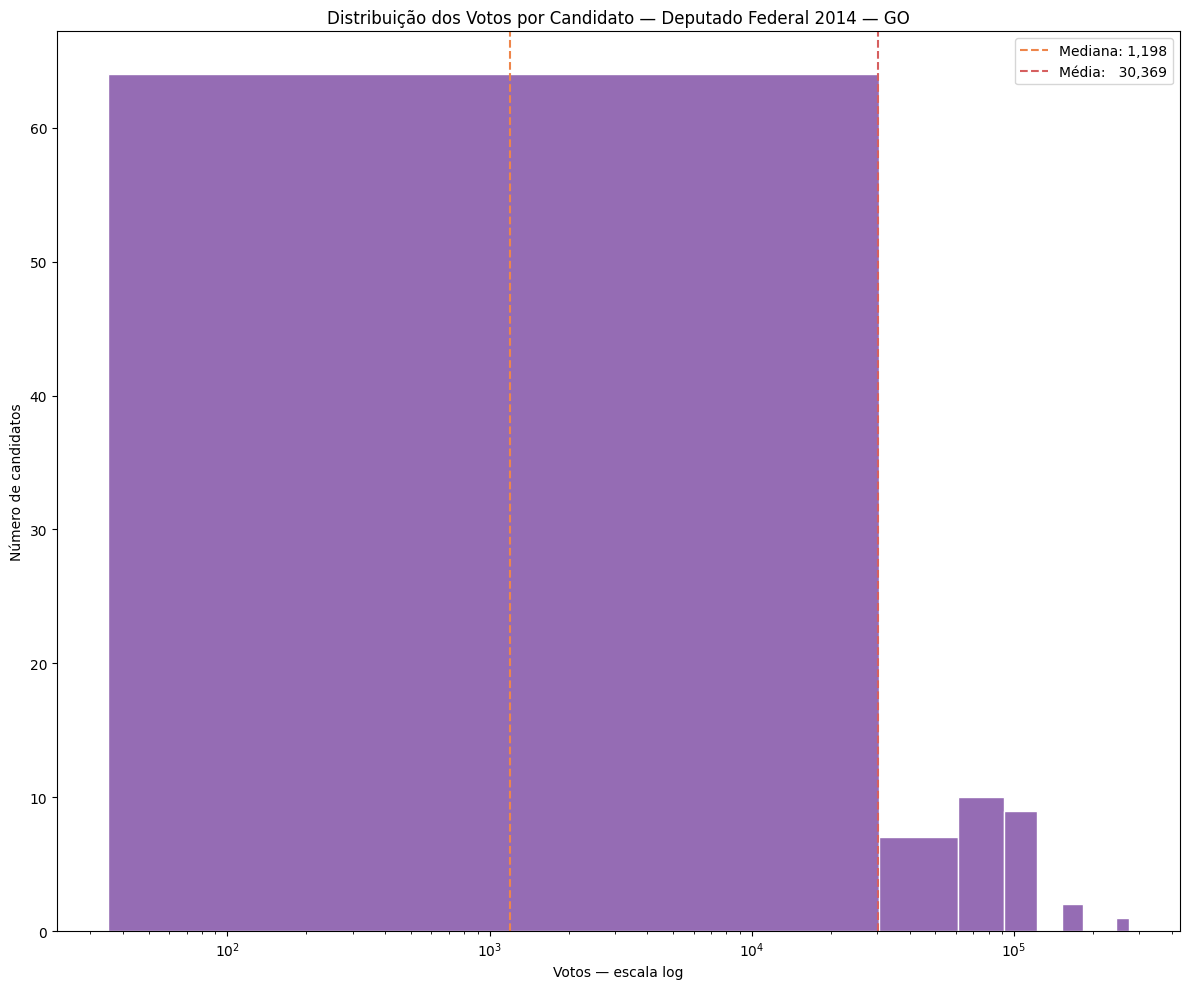

In [221]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(votos_go, bins=n_bins_votos_go, color=CORES[4], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Votos — escala log")
ax.set_ylabel("Número de candidatos")
ax.set_title("Distribuição dos Votos por Candidato — Deputado Federal 2014 — GO")
ax.axvline(
    votos_go.median(),
    color=CORES[1],
    linestyle="--",
    label=f"Mediana: {votos_go.median():,.0f}",
)
ax.axvline(
    votos_go.mean(),
    color=CORES[3],
    linestyle="--",
    label=f"Média:   {votos_go.mean():,.0f}",
)
ax.legend()
plt.tight_layout()
plt.savefig("assets/elections/go_distribuicao_votos.png")
plt.show()

**Observações:**
- distribuição de votos assimétrica à direita, padrão consistente com os demais estados
- `mediana de 1.198 votos` contra `média de 30.369`: afastamento de 25,4x, maior que o do RJ, reflexo dos poucos eleitos com alta votação em um estado com apenas 17 vagas
- com apenas 9 bins a resolução é baixa, mas o padrão de concentração nos menores valores é claro

### <font color=steelblue> 5.5 - Gasto por Partido

#### <font color=slategray> 5.5.1 - Gasto total por Partido

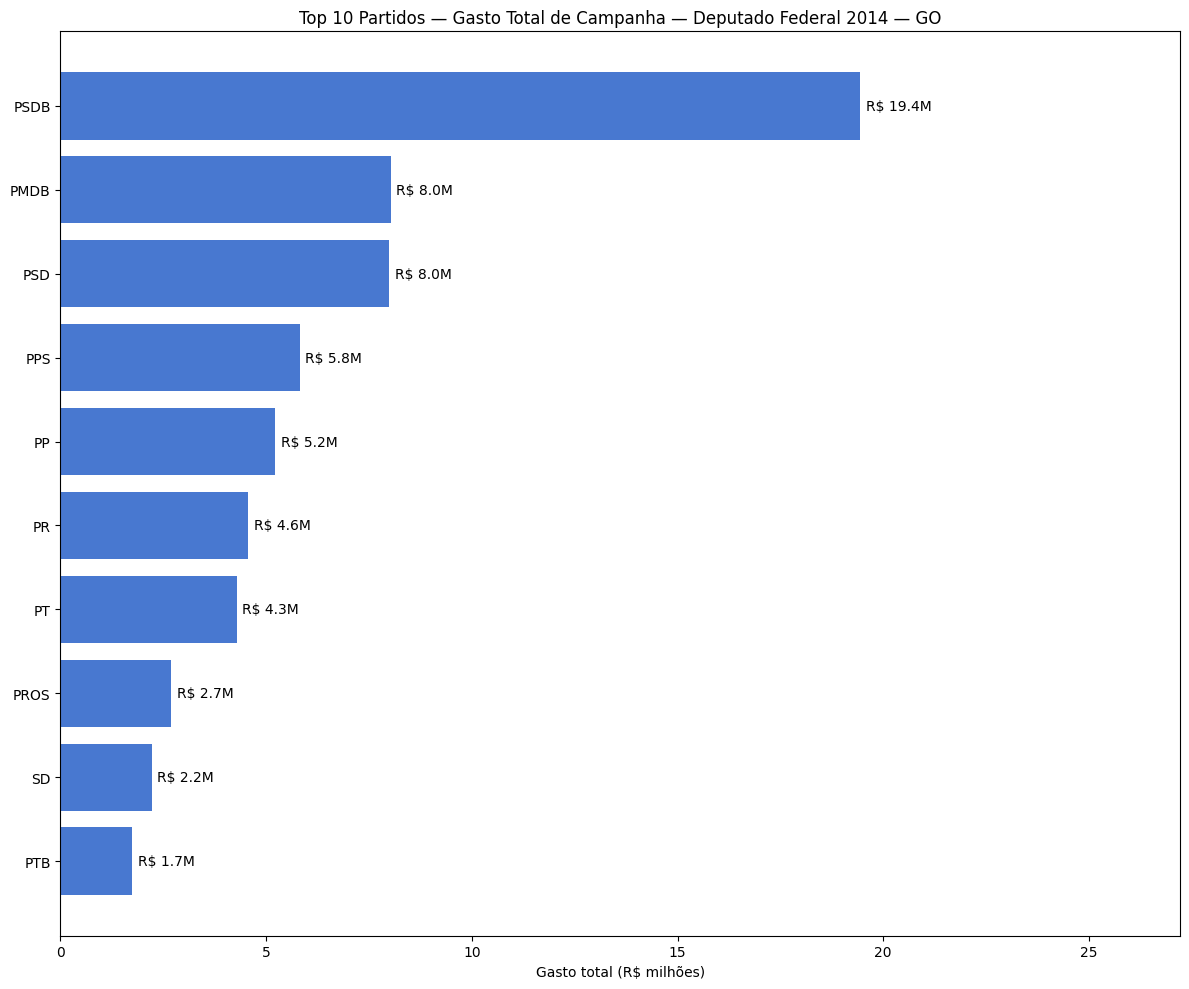

In [222]:
top_total_partido_go = (
    eleicoes_go[eleicoes_go["Gasto"] > 0]
    .groupby("Partido")["Gasto"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(
    top_total_partido_go.index, top_total_partido_go.values / 1e6, color=CORES[0]
)
ax.set_xlabel("Gasto total (R$ milhões)")
ax.set_title("Top 10 Partidos — Gasto Total de Campanha — Deputado Federal 2014 — GO")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4)
ax.set_xlim(0, top_total_partido_go.max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/go_gasto_total_partido.png")
plt.show()

**Observações:**
- PSDB lidera com R$ 19,4M, mais que o dobro do segundo colocado e distante dos demais
- PMDB e PSD empatados em segundo com R$ 8,0M cada
- a concentração no PSDB destoa do padrão nacional onde o partido aparece mas não domina com essa margem

#### <font color=slategray> 5.5.2 - Gasto médio por Partido

o gasto médio por candidato revela quais partidos investem mais por cabeça dentro do GO. partidos com poucos candidatos e alto gasto médio se destacam diferente do ranking de total.

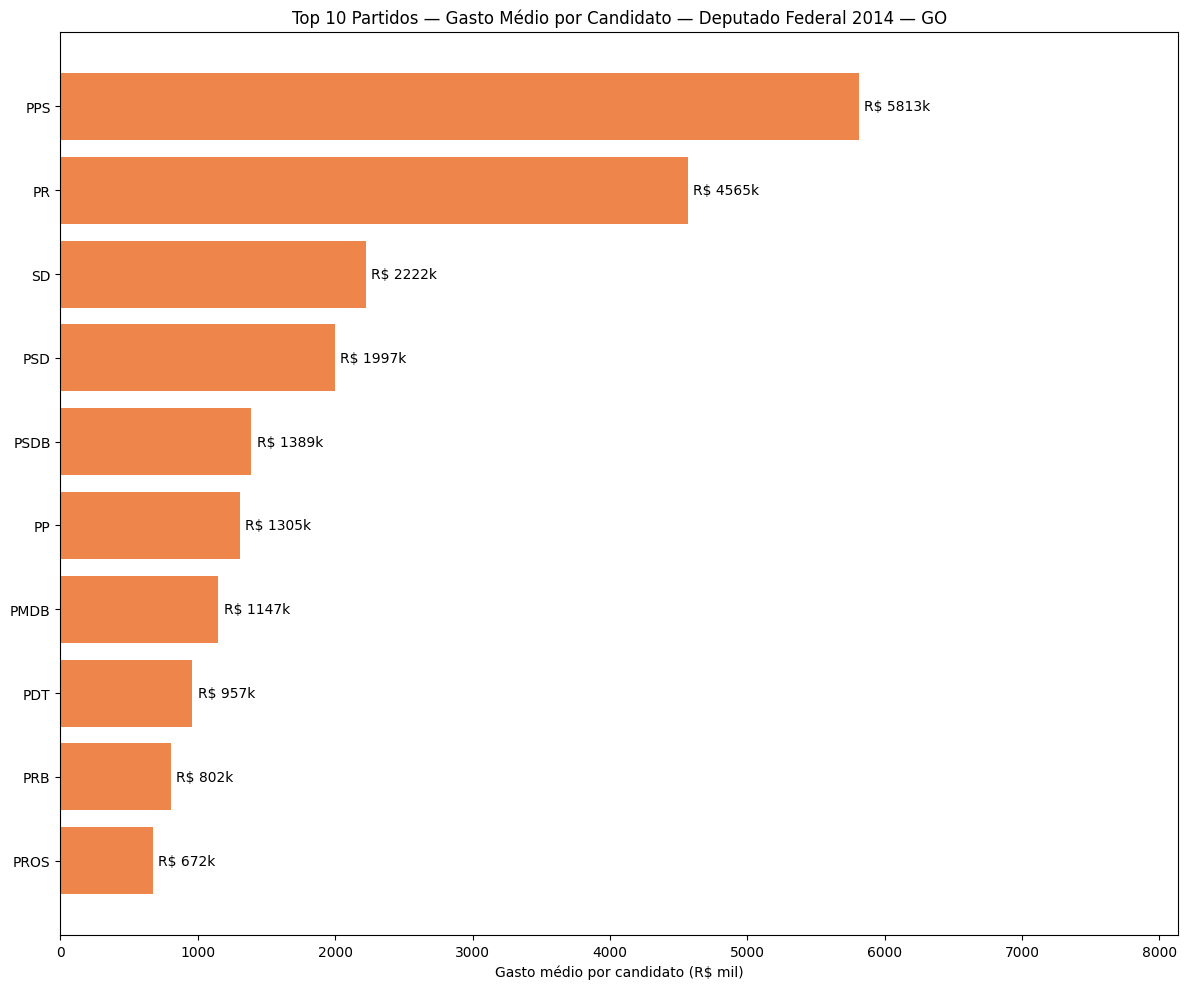

In [223]:
top_media_partido_go = (
    eleicoes_go[eleicoes_go["Gasto"] > 0]
    .groupby("Partido")["Gasto"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(
    top_media_partido_go.index, top_media_partido_go.values / 1e3, color=CORES[1]
)
ax.set_xlabel("Gasto médio por candidato (R$ mil)")
ax.set_title("Top 10 Partidos — Gasto Médio por Candidato — Deputado Federal 2014 — GO")
ax.bar_label(bars, fmt="R$ %.0fk", padding=4)
ax.set_xlim(0, top_media_partido_go.max() / 1e3 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/go_gasto_medio_partido.png")
plt.show()

**Observações:**
- PPS lidera a média com R$ 5,8M por candidato, valor que corresponde ao total do partido: candidato único com gasto extremamente alto
- PR aparece em segundo com R$ 4,6M, também indicando poucos candidatos com alto investimento
- PSDB cai para quinto na média (R$ 1,4M) apesar de liderar o total, pois distribuiu mais candidaturas

### <font color=steelblue> 5.6 - Gasto vs Votos por Situação Eleitoral

uso a mesma função da seção 3.6 passando o filtro de estado para comparar gasto e votos dos candidatos do GO por resultado eleitoral.

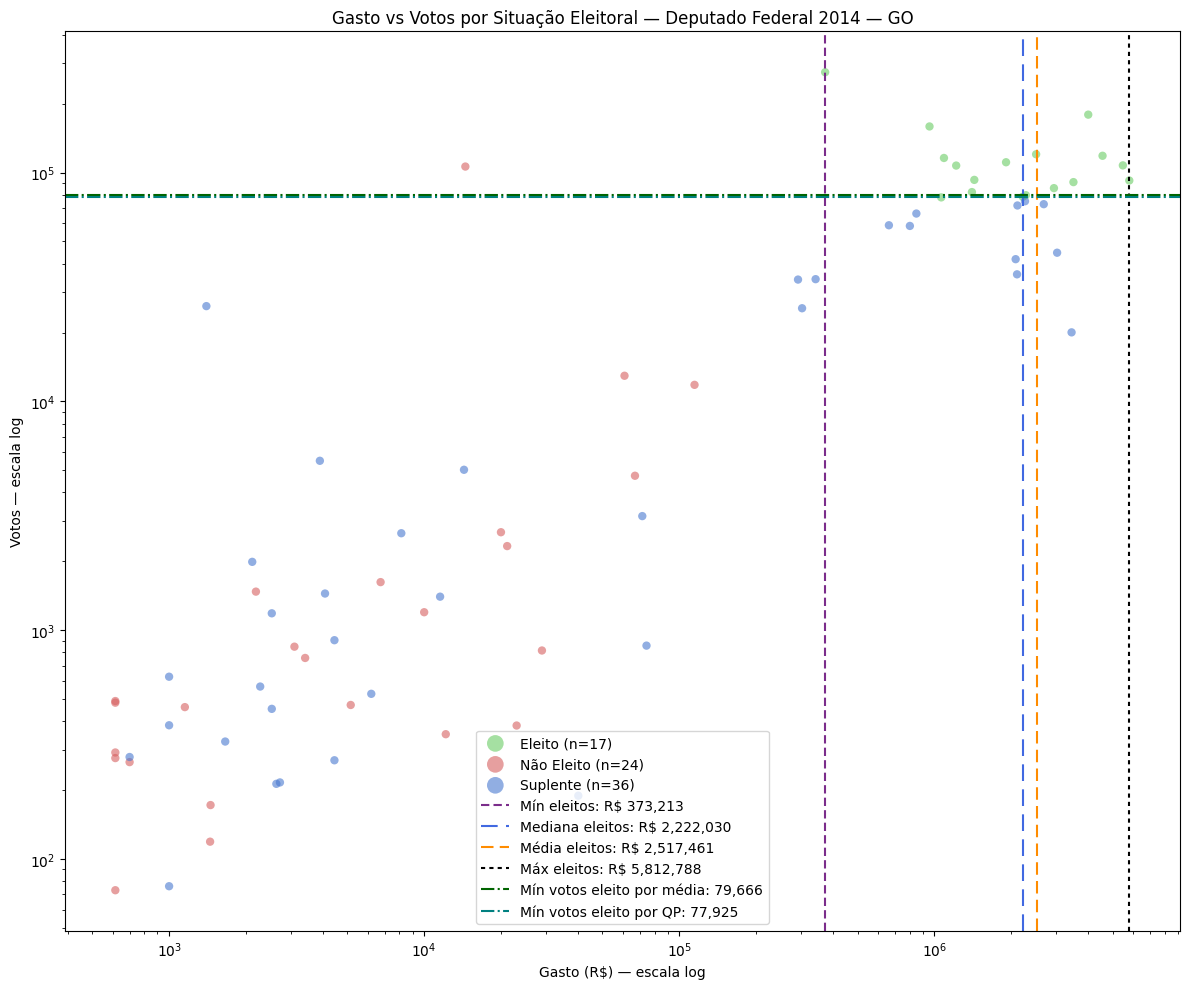

Tabela 5.6 - Gasto e Votos por Resultado Eleitoral — GO


,N,Gasto Médio,Gasto Mediana,Gasto Mín,Gasto Máx,Votos Médios,Votos Mediana
Eleito,17,"R$ 2,517,461","R$ 2,222,030","R$ 373,213","R$ 5,812,788","116,079","107,344"
Suplente,36,"R$ 590,658","R$ 9,841",R$ 700,"R$ 3,451,878","19,271","2,321"
Não Eleito,24,"R$ 16,712","R$ 4,284",R$ 615,"R$ 114,782","6,306",623
Total,77,"R$ 837,164","R$ 21,153",R$ 615,"R$ 5,812,788","36,603","2,680"


In [224]:
plot_gasto_vs_votos(eleicoes_enriquecido, estados=["GO"])
tabela_gasto_vs_votos(eleicoes_enriquecido, "Tabela 5.6 - Gasto e Votos por Resultado Eleitoral — GO", estados=["GO"])

**Observações:**
- GO elege 17 deputados federais; eleitos têm mediana de gasto de R$ 2,2M e mediana de votos de 107.344
- a separação entre eleitos e não eleitos é nítida: não eleitos têm mediana de gasto de R$ 2.645, mais de 800x menor que a dos eleitos
- o padrão de cauda longa se mantém com alguns candidatos de alto gasto sem resultado proporcional em votos

#### <font color=slategray> 5.6.1 - Coeficiente de Pearson e Matriz de Correlação

In [225]:
dados_go = eleicoes_go[["Gasto", "Votos"]].dropna()
dados_go = dados_go[(dados_go["Gasto"] > 0) & (dados_go["Votos"] > 0)]

r_go, p_go = pearsonr(dados_go["Gasto"], dados_go["Votos"])

resultado_go = pd.Series(
    {"Coeficiente de Pearson (r)": round(r_go, 3), "p-valor": round(p_go, 4)},
    name="Gasto × Votos — GO"
)
print("Tabela 5.6.1 — Correlação de Pearson — GO")
display(resultado_go.to_frame())

Tabela 5.6.1 — Correlação de Pearson — GO


,Gasto × Votos — GO
Coeficiente de Pearson (r),0.605
p-valor,0.000


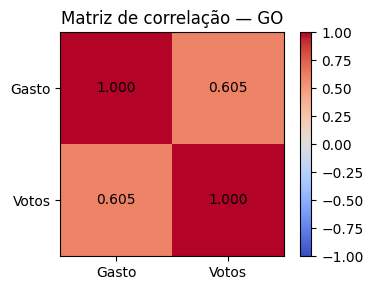

In [226]:
corr_go = dados_go[["Gasto", "Votos"]].corr()

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr_go, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_go.columns)), corr_go.columns)
ax.set_yticks(range(len(corr_go.index)), corr_go.index)
for i in range(len(corr_go)):
    for j in range(len(corr_go.columns)):
        ax.text(j, i, f"{corr_go.iloc[i, j]:.3f}", ha="center", va="center", color="black")
ax.set_title("Matriz de correlação — GO")
plt.tight_layout()
plt.savefig("assets/elections/go_matriz_correlacao.png")
plt.show()

**Observações:**
- o coeficiente de Pearson no GO é de `r = 0,605`, correlação moderada a forte e positiva
- ligeiramente mais alta que no RJ, sugerindo que em Goiás o gasto é um preditor relativamente mais consistente dos votos
- o p-valor confirma a significância estatística da correlação

### <font color=steelblue> 5.7 - Análise de Fornecedores

#### <font color=slategray> 5.7.1 - Gasto por Setor Econômico

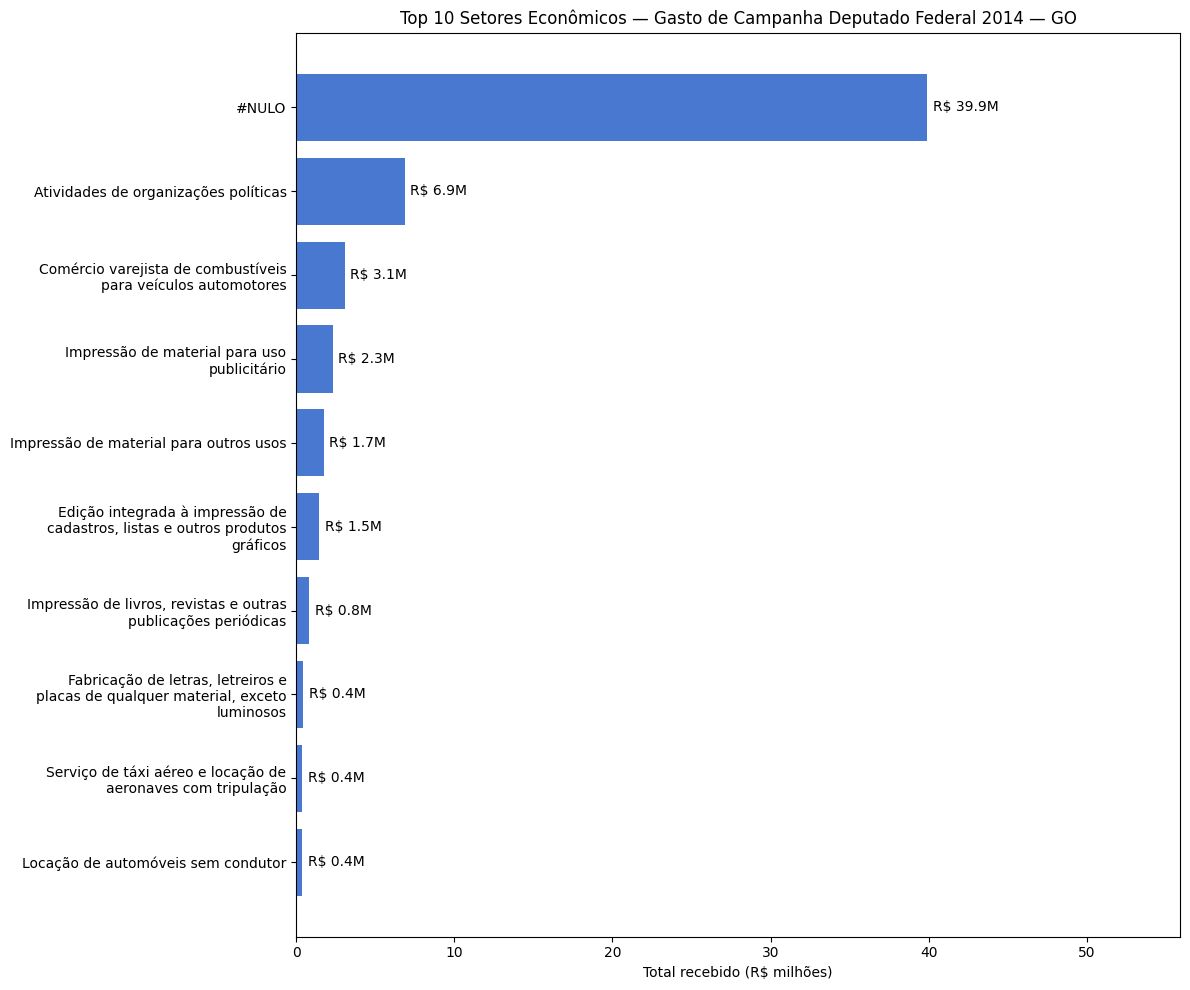

In [227]:
fornecedores_go = fornecedores_df[fornecedores_df["Estado"] == "GO"]

top_setores_go = (
    fornecedores_go.groupby("Setor")["Total_Recebido"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
labels_top_setores_go = [textwrap.fill(s, width=38) for s in top_setores_go.index]
bars = ax.barh(labels_top_setores_go, top_setores_go.values / 1e6, color=CORES[0])
ax.set_xlabel("Total recebido (R$ milhões)")
ax.set_title("Top 10 Setores Econômicos — Gasto de Campanha Deputado Federal 2014 — GO")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4)
ax.set_xlim(0, top_setores_go.max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/go_fornecedores_setores.png")
plt.show()

**Observações:**
- `#NULO` domina com R$ 39,9M (61,3%), a maior proporção entre os três recortes analisados
- organizações políticas em segundo com R$ 6,9M (10,6%)
- combustíveis aparecem novamente em terceiro (4,7%), padrão semelhante ao MT e ausente no RJ
- táxi aéreo aparece no top 10 com R$ 0,4M, refletindo o custo de deslocamento para campanha no interior do estado

#### <font color=slategray> 5.7.2 - Top fornecedores por valor recebido

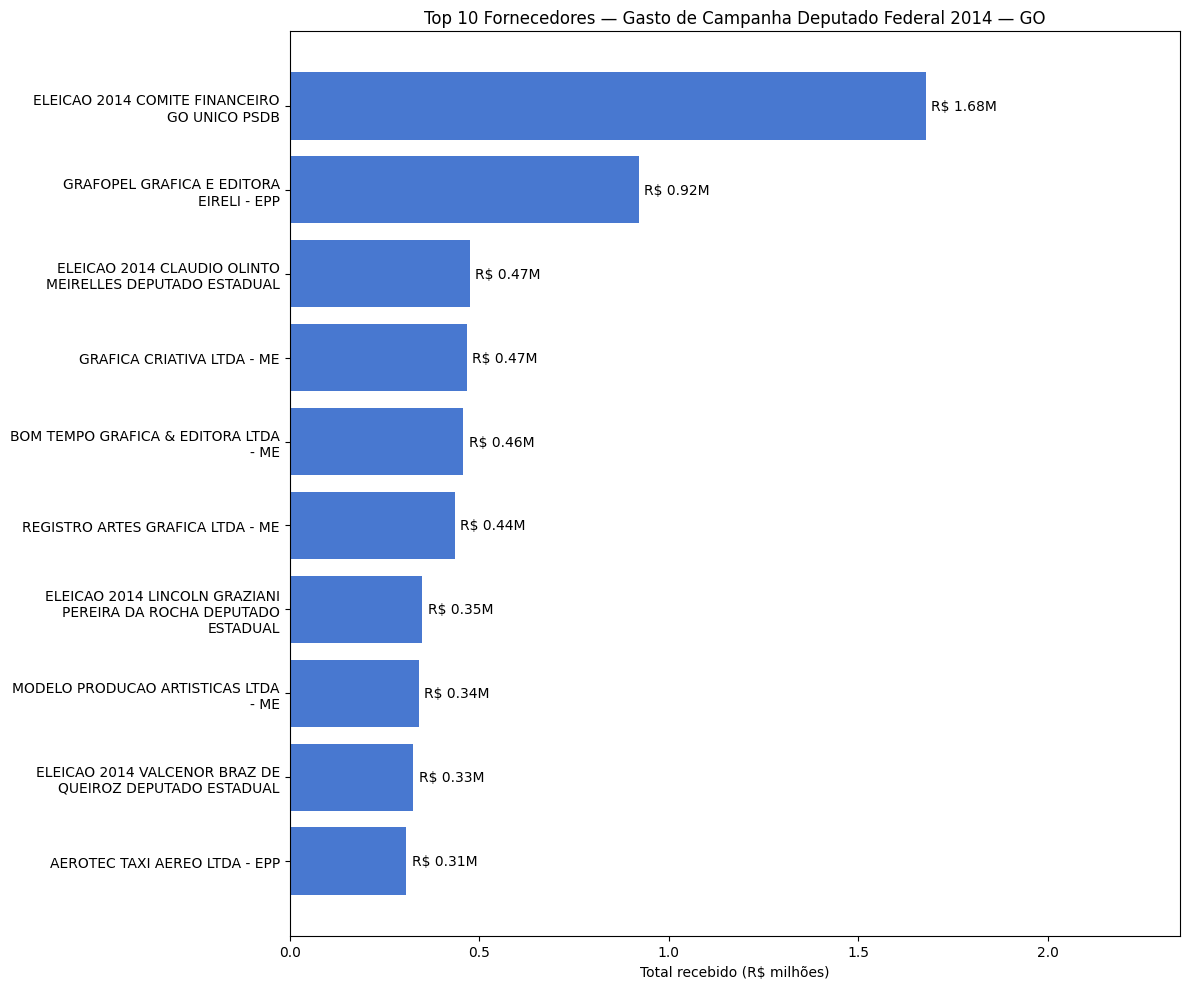

In [228]:
top_fornecedores_go = (
    fornecedores_go.groupby(["CNPJ Fornecedor", "Nome Fornecedor"])
    .agg(
        Total_Recebido=("Total_Recebido", "sum"),
        Qtd_Candidatos=("Numero Candidato", "nunique"),
    )
    .reset_index()
    .sort_values("Total_Recebido", ascending=False)
    .head(10)
    .sort_values("Total_Recebido")
)

fig, ax = plt.subplots(figsize=FIGSIZE)
nomes_top_fornecedores_go = top_fornecedores_go["Nome Fornecedor"].apply(lambda s: textwrap.fill(s, width=32))
bars = ax.barh(
    nomes_top_fornecedores_go,
    top_fornecedores_go["Total_Recebido"] / 1e6,
    color=CORES[0],
)
ax.set_xlabel("Total recebido (R$ milhões)")
ax.set_title("Top 10 Fornecedores — Gasto de Campanha Deputado Federal 2014 — GO")
ax.bar_label(bars, fmt="R$ %.2fM", padding=4)
ax.set_xlim(0, top_fornecedores_go["Total_Recebido"].max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/go_fornecedores_top10.png")
plt.show()

**Observações:**
- o Comitê do PSDB lidera com R$ 1,7M entre 10 candidaturas, padrão de centralização partidária via comitê visto também no RJ
- gráficas locais ocupam as demais posições, sem presença de fornecedores nacionais


## <font color=darkblue> 6 - Análise exploratória dos dados AM

repito as mesmas análises filtrando os candidatos do Amazonas. o estado tem poucos candidatos e apresenta particularidades logísticas de campanha em função da extensão territorial e do isolamento geográfico.

### <font color=steelblue> 6.1 - Visão geral do dataset

In [229]:
eleicoes_am = eleicoes_enriquecido[eleicoes_enriquecido["Estado"] == "AM"].copy()

print("Tabela 6.1 — Estatísticas descritivas do dataset das Eleições de 2014 — AM")
display(
    eleicoes_am.describe()
    .drop(columns=["Numero Candidato", "CPF", "Votos"])
    .T.map(lambda x: f"{x:,.2f}")
)

Tabela 6.1 — Estatísticas descritivas do dataset das Eleições de 2014 — AM


,count,mean,std,min,25%,50%,75%,max
Gasto,80.00,"292,684.08","816,944.21",0.00,815.62,"4,153.99","50,072.03","5,633,092.26"
Qtd_Notas,80.00,202.12,479.30,0.00,2.00,7.00,49.00,"2,294.00"
Total_Despesas_TSE,68.00,"344,893.77","876,647.94",100.00,"1,827.94","8,496.40","129,509.26","5,633,092.26"


**Observações:**
- AM tem 80 candidatos ao cargo de Deputado Federal, 67 (84%) com gasto registrado
- média de gasto de R$ 292.684 com desvio padrão de R$ 816.944, quase 3x a média, evidenciando forte dispersão
- votos máximos de 250.916, compatível com o tamanho do eleitorado amazonense

### <font color=steelblue> 6.2 - Cálculo do bins

In [230]:
mask_com_gasto_am = eleicoes_am["Gasto"] > 0
gastos_am = eleicoes_am[mask_com_gasto_am]["Gasto"]

n_bins_am = int(np.sqrt(len(gastos_am)))

largura_linear_am = (gastos_am.max() - gastos_am.min()) / n_bins_am

resumo_bins_am = pd.DataFrame(
    {
        "Parâmetro": [
            "Candidatos com gasto > 0",
            "Número de bins (√n)",
            "Gasto mínimo",
            "Gasto máximo",
            "Largura de cada bin (linear)",
        ],
        "Valor": [
            f"{len(gastos_am):,}",
            f"{n_bins_am}",
            f"R$ {gastos_am.min():,.2f}",
            f"R$ {gastos_am.max():,.2f}",
            f"R$ {largura_linear_am:,.2f}",
        ],
    }
)

print("Tabela 6.2 - Parâmetros do histograma — AM")
display(resumo_bins_am.set_index("Parâmetro"))

Tabela 6.2 - Parâmetros do histograma — AM


,Valor
Parâmetro,
Candidatos com gasto > 0,67
Número de bins (√n),8
Gasto mínimo,R$ 100.00
Gasto máximo,"R$ 5,633,092.26"
Largura de cada bin (linear),"R$ 704,124.03"


**Observações:**
- apenas 67 candidatos com gasto geram 8 bins pela regra da raiz quadrada, o menor número entre todos os estados analisados
- amplitude de R$ 100 a R$ 5,6M resulta em largura linear de R$ 704k por bin, a maior entre os estados analisados
- a resolução do histograma é baixa dado o número reduzido de observações

### <font color=steelblue> 6.3 - Distribuição do Gasto por Candidato

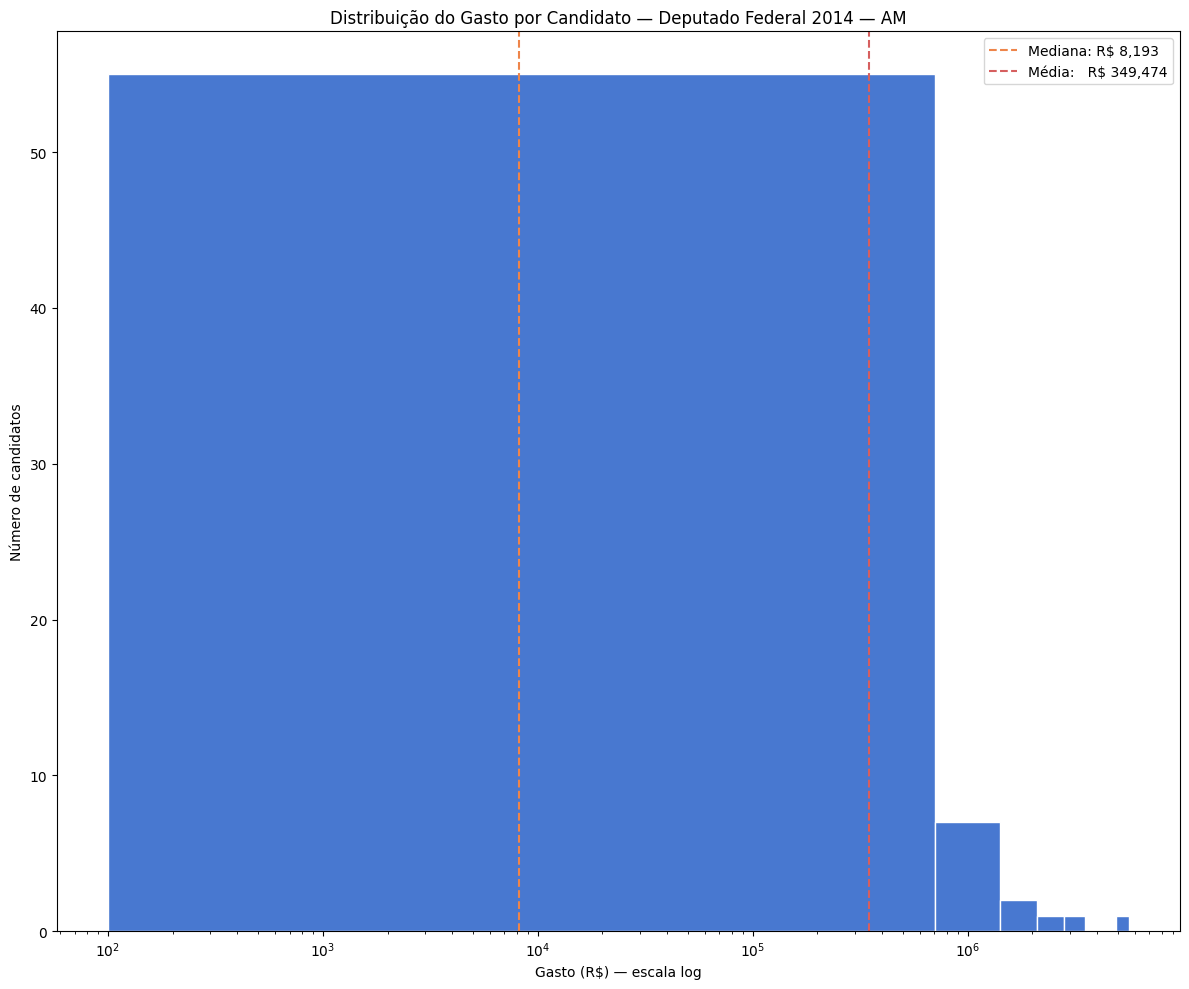

In [231]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(gastos_am, bins=n_bins_am, color=CORES[0], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Gasto (R$) — escala log")
ax.set_ylabel("Número de candidatos")
ax.set_title("Distribuição do Gasto por Candidato — Deputado Federal 2014 — AM")
ax.axvline(
    gastos_am.median(),
    color=CORES[1],
    linestyle="--",
    label=f"Mediana: R$ {gastos_am.median():,.0f}",
)
ax.axvline(
    gastos_am.mean(),
    color=CORES[3],
    linestyle="--",
    label=f"Média:   R$ {gastos_am.mean():,.0f}",
)
ax.legend()
plt.tight_layout()
plt.savefig("assets/elections/am_distribuicao_gasto.png")
plt.show()

**Observações:**
- distribuição assimétrica à direita, padrão consistente com os demais estados e com o Brasil
- `mediana de R$ 8.193` contra `média de R$ 349.474`: afastamento de 42,7x, entre os valores do RJ (22,7x) e do GO (125,7x)
- a mediana do AM (R$ 8.193) é próxima à nacional (R$ 9.916), sugerindo que o candidato típico gasta em nível semelhante ao do restante do país
- a cauda direita é puxada por poucos candidatos com gastos acima de R$ 1M

### <font color=steelblue> 6.4 - Distribuição dos Votos por Candidato

In [232]:
votos_am = eleicoes_am[eleicoes_am["Votos"] > 0]["Votos"]

n_bins_votos_am = int(np.sqrt(len(votos_am)))

largura_linear_votos_am = (votos_am.max() - votos_am.min()) / n_bins_votos_am

resumo_bins_votos_am = pd.DataFrame(
    {
        "Parâmetro": [
            "Candidatos com votos > 0",
            "Número de bins (√n)",
            "Votos mínimo",
            "Votos máximo",
            "Largura de cada bin (linear)",
        ],
        "Valor": [
            f"{len(votos_am):,}",
            f"{n_bins_votos_am}",
            f"{votos_am.min():,.0f}",
            f"{votos_am.max():,.0f}",
            f"{largura_linear_votos_am:,.0f}",
        ],
    }
)

print("Tabela 6.4 - Parâmetros do histograma de votos — AM")
display(resumo_bins_votos_am.set_index("Parâmetro"))

Tabela 6.4 - Parâmetros do histograma de votos — AM


,Valor
Parâmetro,
Candidatos com votos > 0,76
Número de bins (√n),8
Votos mínimo,32
Votos máximo,"250,916"
Largura de cada bin (linear),"31,360"


**Observações:**

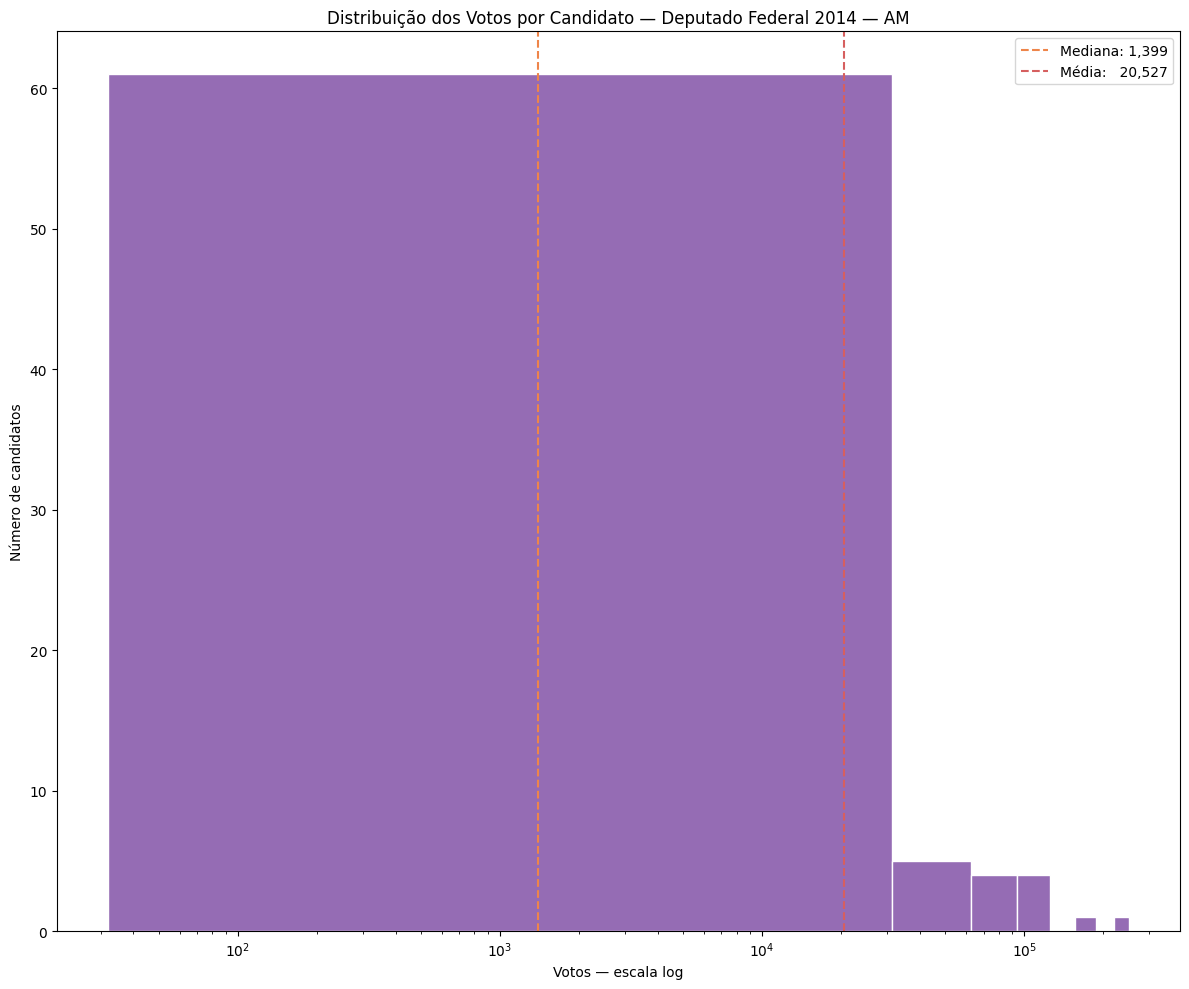

In [233]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(votos_am, bins=n_bins_votos_am, color=CORES[4], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Votos — escala log")
ax.set_ylabel("Número de candidatos")
ax.set_title("Distribuição dos Votos por Candidato — Deputado Federal 2014 — AM")
ax.axvline(
    votos_am.median(),
    color=CORES[1],
    linestyle="--",
    label=f"Mediana: {votos_am.median():,.0f}",
)
ax.axvline(
    votos_am.mean(),
    color=CORES[3],
    linestyle="--",
    label=f"Média:   {votos_am.mean():,.0f}",
)
ax.legend()
plt.tight_layout()
plt.savefig("assets/elections/am_distribuicao_votos.png")
plt.show()

**Observações:**
- distribuição de votos assimétrica à direita, padrão mantido nos três estados analisados
- `mediana de 1.399 votos` contra `média de 20.527`: afastamento de 14,7x
- com apenas 8 bins a resolução é mínima, mas a concentração na faixa de baixos votos é evidente; a cauda chega a 250.916 votos puxada pelos 8 eleitos

### <font color=steelblue> 6.5 - Gasto por Partido

#### <font color=slategray> 6.5.1 - Gasto total por Partido

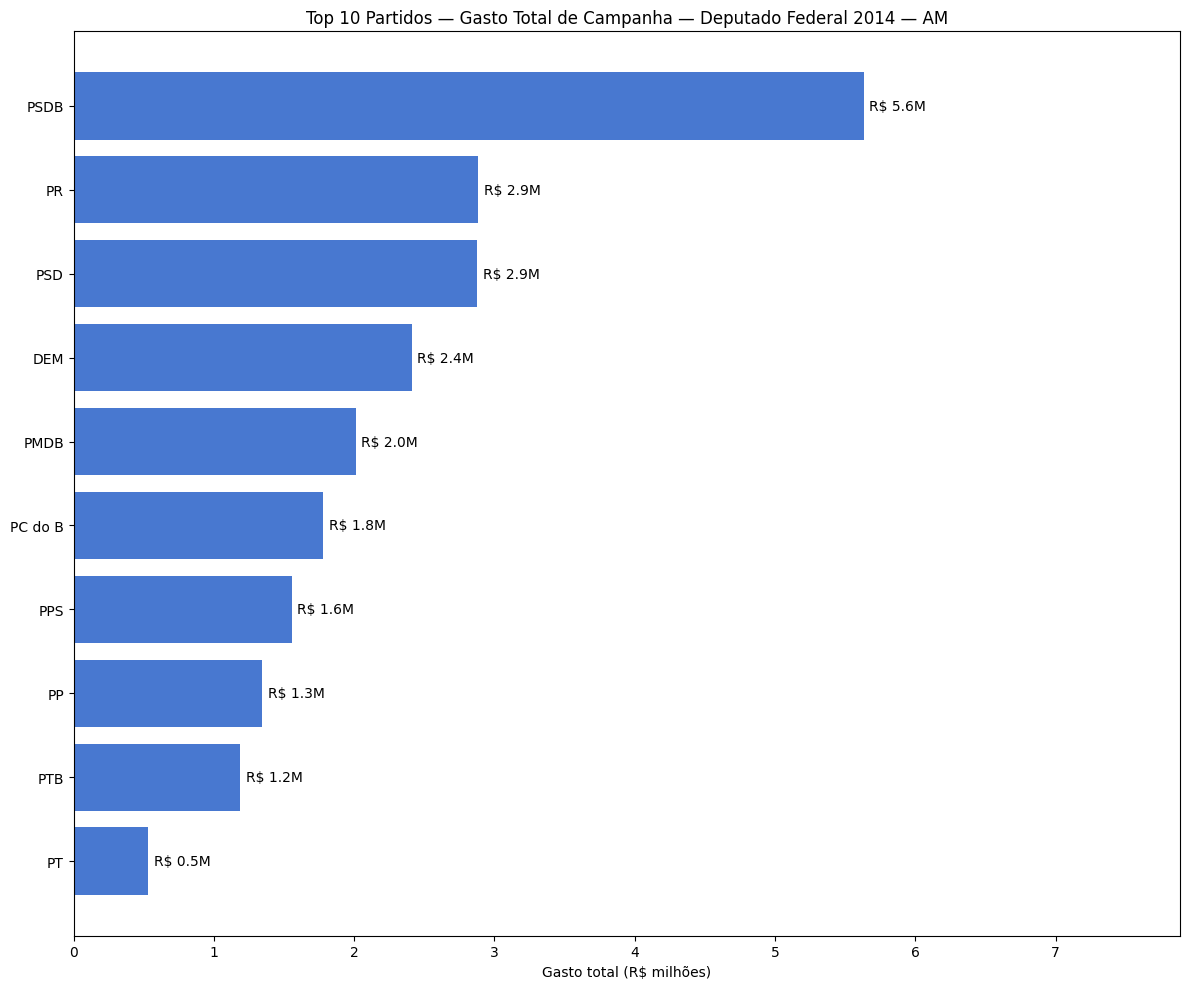

In [234]:
top_total_partido_am = (
    eleicoes_am[eleicoes_am["Gasto"] > 0]
    .groupby("Partido")["Gasto"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(
    top_total_partido_am.index, top_total_partido_am.values / 1e6, color=CORES[0]
)
ax.set_xlabel("Gasto total (R$ milhões)")
ax.set_title("Top 10 Partidos — Gasto Total de Campanha — Deputado Federal 2014 — AM")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4)
ax.set_xlim(0, top_total_partido_am.max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/am_gasto_total_partido.png")
plt.show()

**Observações:**
- PSDB lidera com R$ 5,6M, quase o dobro do segundo colocado
- PR e PSD empatados em segundo com R$ 2,9M cada
- o total geral é menor que nos demais estados analisados, reflexo do número reduzido de candidatos

#### <font color=slategray> 6.5.2 - Gasto médio por Partido

o gasto médio por candidato revela quais partidos investem mais por cabeça dentro do AM. partidos com poucos candidatos e alto gasto médio se destacam diferente do ranking de total.

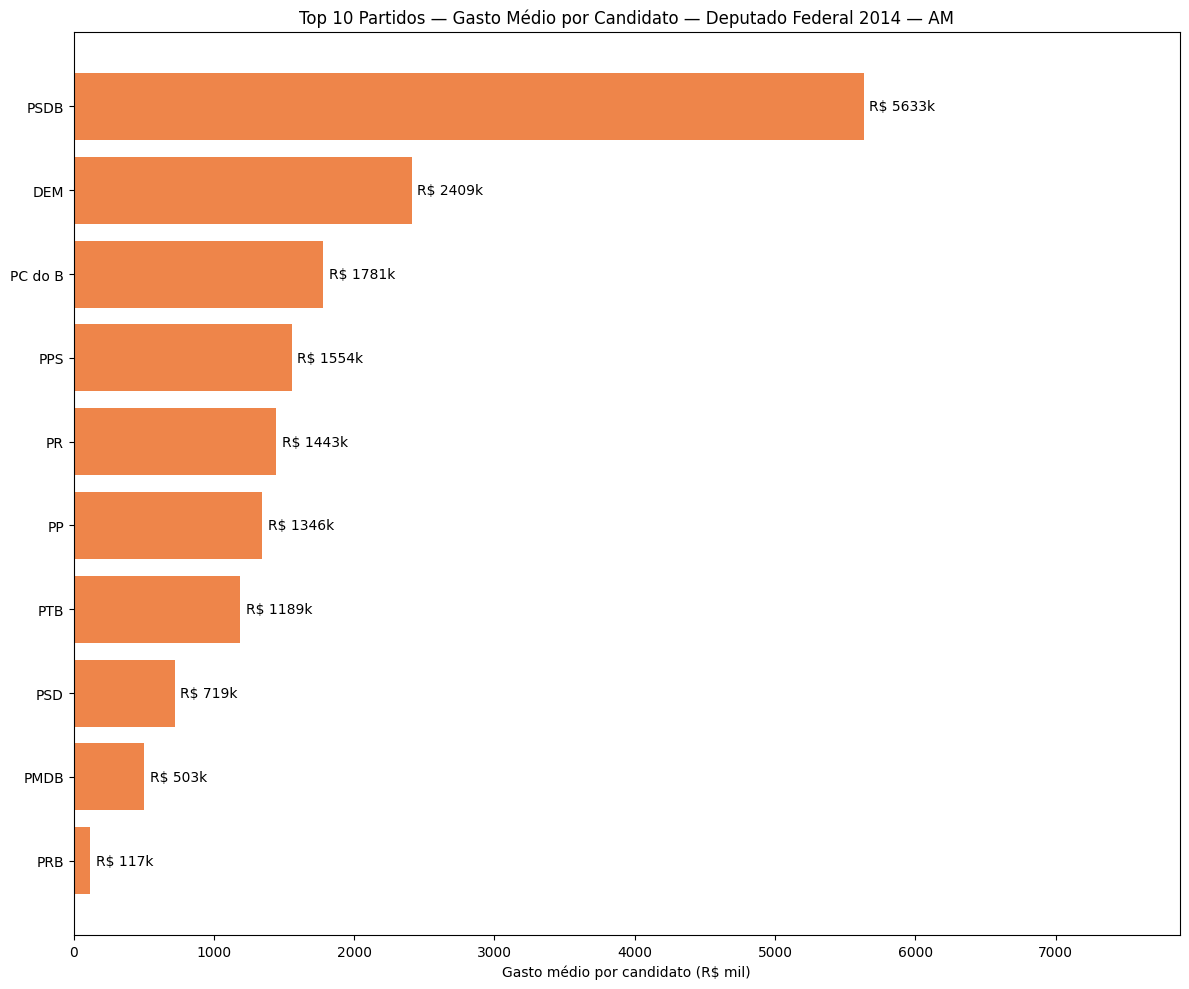

In [235]:
top_media_partido_am = (
    eleicoes_am[eleicoes_am["Gasto"] > 0]
    .groupby("Partido")["Gasto"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(
    top_media_partido_am.index, top_media_partido_am.values / 1e3, color=CORES[1]
)
ax.set_xlabel("Gasto médio por candidato (R$ mil)")
ax.set_title("Top 10 Partidos — Gasto Médio por Candidato — Deputado Federal 2014 — AM")
ax.bar_label(bars, fmt="R$ %.0fk", padding=4)
ax.set_xlim(0, top_media_partido_am.max() / 1e3 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/am_gasto_medio_partido.png")
plt.show()

**Observações:**
- PSDB mantém a liderança também na média com R$ 5,6M por candidato: total e média coincidem, indicando candidato único no partido com gasto máximo do estado
- DEM aparece em segundo com R$ 2,4M, partido que não figurava no topo do total
- a partir do terceiro colocado os valores caem abruptamente, acentuando a concentração nos dois primeiros

### <font color=steelblue> 6.6 - Gasto vs Votos por Situação Eleitoral

uso a mesma função da seção 3.6 passando o filtro de estado para comparar gasto e votos dos candidatos do AM por resultado eleitoral.

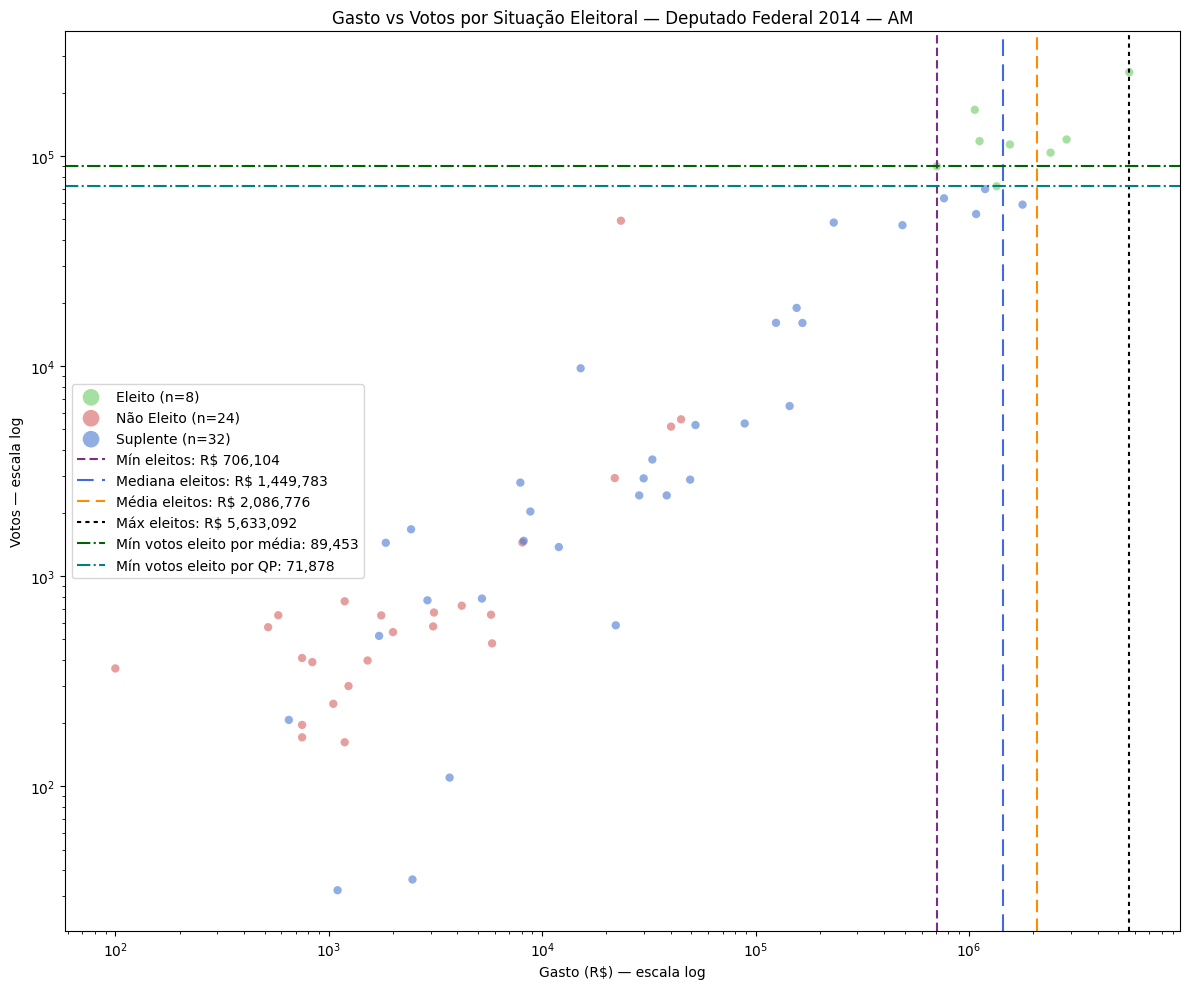

Tabela 6.6 - Gasto e Votos por Resultado Eleitoral — AM


,N,Gasto Médio,Gasto Mediana,Gasto Mín,Gasto Máx,Votos Médios,Votos Mediana
Eleito,8,"R$ 2,086,776","R$ 1,449,783","R$ 706,104","R$ 5,633,092","129,262","115,800"
Suplente,32,"R$ 204,330","R$ 29,176",R$ 650,"R$ 1,780,867","13,928","2,838"
Não Eleito,24,"R$ 7,268","R$ 1,641",R$ 100,"R$ 44,744","3,055",574
Total,64,"R$ 365,738","R$ 10,382",R$ 100,"R$ 5,633,092","24,268","1,853"


In [236]:
plot_gasto_vs_votos(eleicoes_enriquecido, estados=["AM"])
tabela_gasto_vs_votos(eleicoes_enriquecido, "Tabela 6.6 - Gasto e Votos por Resultado Eleitoral — AM", estados=["AM"])

**Observações:**
- AM elege 8 deputados federais; eleitos têm mediana de gasto de R$ 1,4M e mediana de votos de 115.800
- não eleitos têm mediana de gasto de R$ 1.188, mais de 1.200x menor que a dos eleitos, a maior separação entre os estados analisados
- suplentes têm mediana de gasto de R$ 18.631, valor mais próximo dos não eleitos que dos eleitos

#### <font color=slategray> 6.6.1 - Coeficiente de Pearson e Matriz de Correlação

In [237]:
dados_am = eleicoes_am[["Gasto", "Votos"]].dropna()
dados_am = dados_am[(dados_am["Gasto"] > 0) & (dados_am["Votos"] > 0)]

r_am, p_am = pearsonr(dados_am["Gasto"], dados_am["Votos"])

resultado_am = pd.Series(
    {"Coeficiente de Pearson (r)": round(r_am, 3), "p-valor": round(p_am, 4)},
    name="Gasto × Votos — AM"
)
print("Tabela 6.6.1 — Correlação de Pearson — AM")
display(resultado_am.to_frame())

Tabela 6.6.1 — Correlação de Pearson — AM


,Gasto × Votos — AM
Coeficiente de Pearson (r),0.902
p-valor,0.000


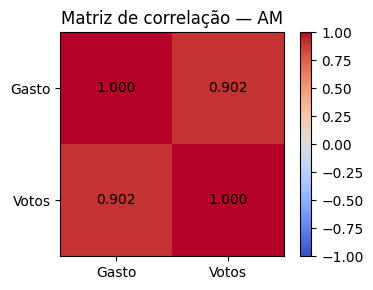

In [238]:
corr_am = dados_am[["Gasto", "Votos"]].corr()

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr_am, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_am.columns)), corr_am.columns)
ax.set_yticks(range(len(corr_am.index)), corr_am.index)
for i in range(len(corr_am)):
    for j in range(len(corr_am.columns)):
        ax.text(j, i, f"{corr_am.iloc[i, j]:.3f}", ha="center", va="center", color="black")
ax.set_title("Matriz de correlação — AM")
plt.tight_layout()
plt.savefig("assets/elections/am_matriz_correlacao.png")
plt.show()

**Observações:**
- o coeficiente de Pearson no AM é de `r = 0,902`, a correlação mais forte entre os três estados analisados, classificada como forte e positiva
- o pequeno número de candidatos (64 com gasto e votos) pode amplificar o efeito de poucos outliers, mas a tendência linear é muito mais clara que nos demais estados
- o p-valor é praticamente zero, confirmando alta significância estatística

### <font color=steelblue> 6.7 - Análise de Fornecedores

#### <font color=slategray> 6.7.1 - Gasto por Setor Econômico

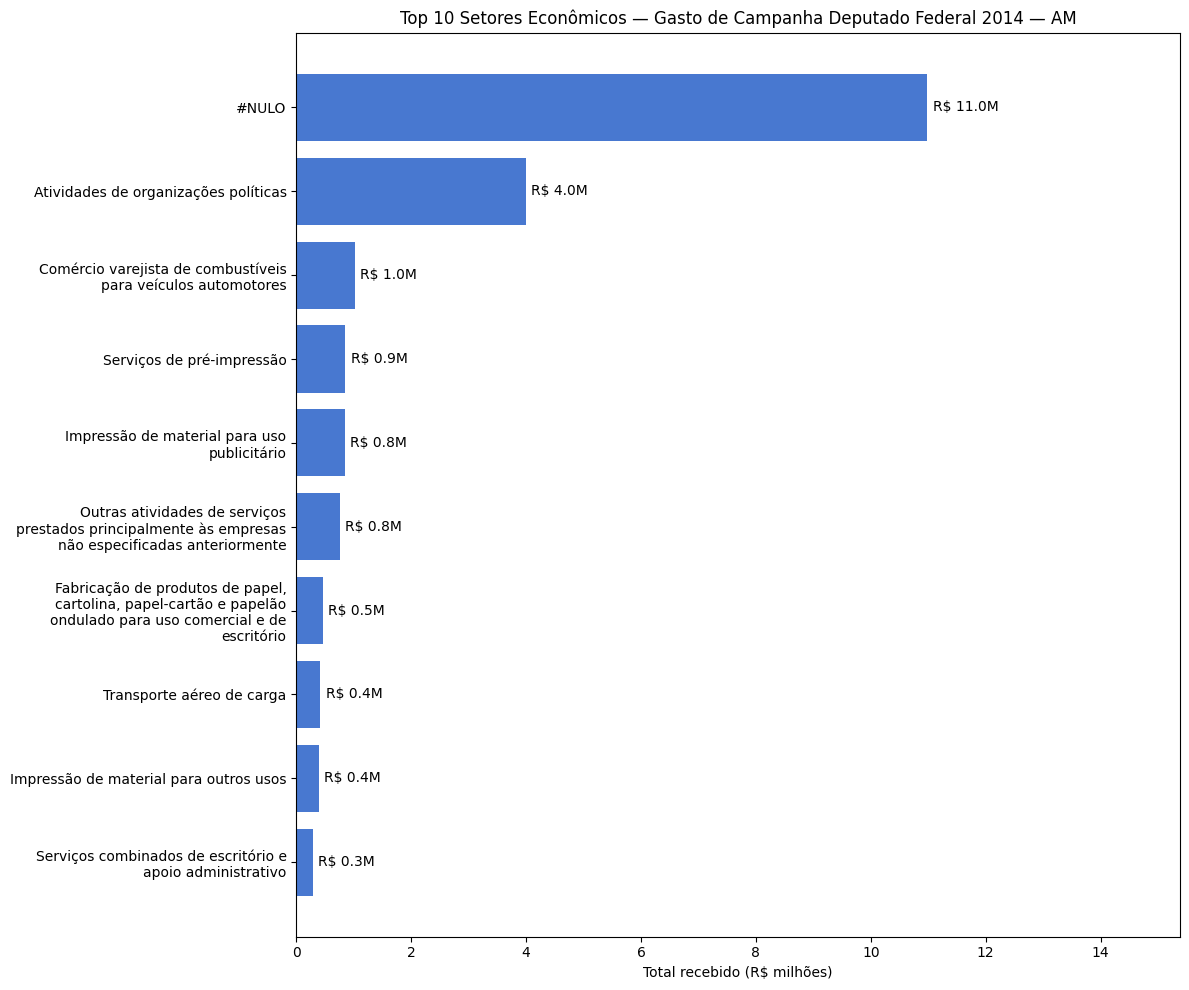

In [239]:
fornecedores_am = fornecedores_df[fornecedores_df["Estado"] == "AM"]

top_setores_am = (
    fornecedores_am.groupby("Setor")["Total_Recebido"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
labels_top_setores_am = [textwrap.fill(s, width=38) for s in top_setores_am.index]
bars = ax.barh(labels_top_setores_am, top_setores_am.values / 1e6, color=CORES[0])
ax.set_xlabel("Total recebido (R$ milhões)")
ax.set_title("Top 10 Setores Econômicos — Gasto de Campanha Deputado Federal 2014 — AM")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4)
ax.set_xlim(0, top_setores_am.max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/am_fornecedores_setores.png")
plt.show()

**Observações:**
- `#NULO` lidera com R$ 11,0M (46,8%), proporção intermediária entre o RJ (28,8%) e o GO (61,3%)
- organizações políticas em segundo com R$ 4,0M (17,0%), padrão consistente com os demais estados
- transporte aéreo de carga aparece no top 10 com R$ 0,4M (1,8%), reflexo das dificuldades logísticas de campanha em um estado com poucos acessos terrestres

#### <font color=slategray> 6.7.2 - Top fornecedores por valor recebido

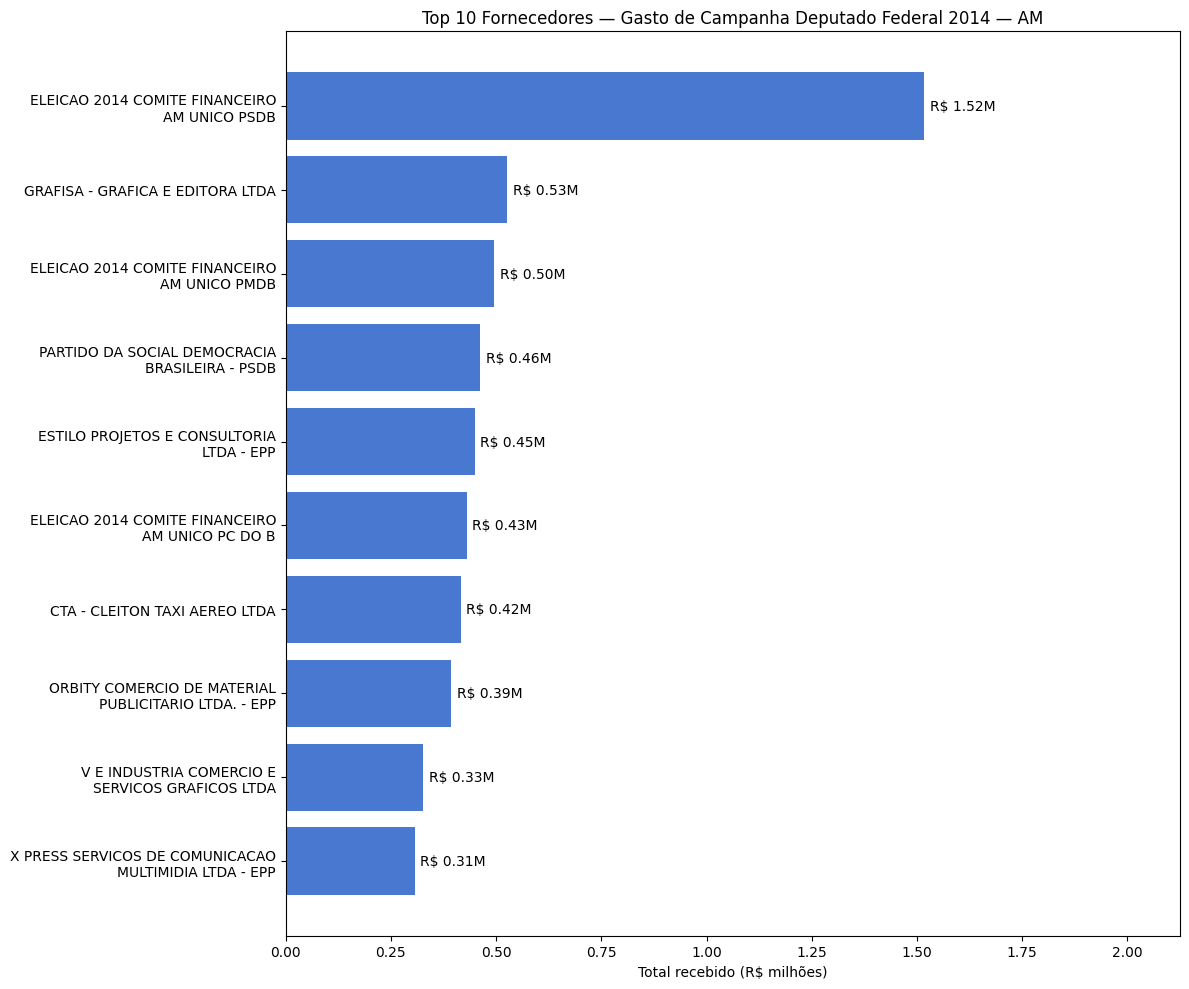

In [240]:
top_fornecedores_am = (
    fornecedores_am.groupby(["CNPJ Fornecedor", "Nome Fornecedor"])
    .agg(
        Total_Recebido=("Total_Recebido", "sum"),
        Qtd_Candidatos=("Numero Candidato", "nunique"),
    )
    .reset_index()
    .sort_values("Total_Recebido", ascending=False)
    .head(10)
    .sort_values("Total_Recebido")
)

fig, ax = plt.subplots(figsize=FIGSIZE)
nomes_top_fornecedores_am = top_fornecedores_am["Nome Fornecedor"].apply(lambda s: textwrap.fill(s, width=32))
bars = ax.barh(
    nomes_top_fornecedores_am,
    top_fornecedores_am["Total_Recebido"] / 1e6,
    color=CORES[0],
)
ax.set_xlabel("Total recebido (R$ milhões)")
ax.set_title("Top 10 Fornecedores — Gasto de Campanha Deputado Federal 2014 — AM")
ax.bar_label(bars, fmt="R$ %.2fM", padding=4)
ax.set_xlim(0, top_fornecedores_am["Total_Recebido"].max() / 1e6 * 1.4)
plt.tight_layout()
plt.savefig("assets/elections/am_fornecedores_top10.png")
plt.show()

**Observações:**
- o Comitê do PSDB lidera com R$ 1,52M concentrado em 1 candidatura, a maior concentração individual entre os fornecedores do estado
- dois serviços de táxi aéreo aparecem no top 10 (CTA Cleiton e implicitamente no transporte aéreo), padrão único entre os estados analisados e coerente com a geografia amazônica
- múltiplos comitês partidários figuram no ranking (PSDB, PMDB, PC do B), indicando centralização de repasses via estrutura partidária